# UBS and JPMorgan earnings calls: sentence embeddings and cross-bank comparison

Willian Angelo · Team 10 · Bank of England employer project (CAM_DS_401) · release `2026-09-23`

Outputs print transcript text. **Clear all outputs before every commit** (public repo, N23).

## Environment

Team setup cell with `NAME = "angelo"`, then `EXPORT = "2026-09-23"` and the smoke test. The cells below expect `ROOT`, `DATA`, `EXPORT` and `loading`.

In [2]:
# 0.0 local Windows only, run before the setup cell: pandas loads pyarrow, whose bundled msvcp140.dll
# is older than the one torch needs, and torch then fails with WinError 1114. Harmless in Colab.
import torch

> **Business view.** A technical safety step with no analysis in it. On Windows, two libraries clash if they load in the wrong order, and the embedding models then refuse to start (R19). Loading PyTorch first keeps the pipeline repeatable on any team laptop. That matters because a supervisor has to be able to rerun the same analysis and get the same numbers.

In [3]:
# Phase 0: paste the team setup cell here (NAME = "angelo"), pin EXPORT = "2026-09-23", smoke test

In [4]:
# project setup - run first, do not edit except NAME
NAME = "angelo"  # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

ok  python 3.13.15  pandas 2.2.3  data c:\local_CAM\Emp_Proj\boe-financial-analysis\data


> **Business view.** The team's standard start-up cell. It finds the project folder, syncs the code with the shared `main` branch, installs the pinned library versions and checks the environment. The output confirms Python 3.13.15 and pandas 2.2.3, the same versions as the rest of the team, so any number on our slides can be reproduced by a teammate or by a Bank of England reviewer.

In [5]:
print("exports:", loading.exports(DATA))
print("files:  ", loading.files(DATA, loading.LATEST))
print("banks:  ", loading.firms(DATA, loading.LATEST))

exports: ['2026-09-13', '2026-09-23', 'Never ever upload or change something in the folder above']
files:   []
banks:   []


> **Business view.** A quick look at which data releases exist: 13 and 23 September. `files` and `banks` come back empty because of a known bug in the team loader. The warning folder "Never ever upload…" sorts after the dates, so "latest" points at it instead of at a release (N18, reported to Roman). This notebook avoids the problem by naming the release explicitly in the next cell.

In [6]:
EXPORT = "2026-09-23"  # pin the export this notebook was written against

sentences_df = loading.load(DATA, "all_sentences.csv", EXPORT)

loaded all_sentences.csv  9519 rows


> **Business view.** The analysis is pinned to one frozen data release (23 September, 9,519 transcript sentences). Every result below traces back to this exact version of the data, the same way a supervisor quotes a specific regulatory return rather than "the latest figures".

In [7]:
sentences_df

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19308,1,"Good morning, ladies and gentlemen."
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19309,2,Welcome to JPMorgan Chase’s First Quarter 2023...
2,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19310,3,This call is being recorded.
3,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19311,4,Your line will be muted for the duration of th...
4,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19312,5,We will now go live to the presentation.
...,...,...,...,...,...,...,...,...,...,...,...,...
9514,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19303,2,So there are no more questions.
9515,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19304,3,There are no more questions.
9516,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19305,4,So thank you for calling in and for your quest...
9517,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19306,5,So I'll touch base next quarter.


> **Business view.** A first look at the raw material: one row per sentence, tagged with bank, quarter, call type, section (prepared remarks or Q&A), speaker role and speaker name. These tags are what let us ask business questions such as "what did UBS management say about capital in 2024?" without reading 17 transcripts by hand.

## Data import and cleaning

In [8]:
# 1.0 settings shared by every phase
try:
    import torch
except OSError as e:
    raise OSError("torch failed to load because pandas loaded first: restart the kernel "
                  "and run the 0.0 cell before the setup cell") from e
import re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for name in ("ROOT", "DATA", "EXPORT", "loading"):
    if name not in globals():
        raise NameError(f"run the Environment cell first: {name} is not defined")
if EXPORT not in loading.exports(DATA):
    raise FileNotFoundError(f"release {EXPORT} is not in {DATA / 'results'}")

SEED = 42
OUT = ROOT / "notebooks" / "angelo" / "outputs" / EXPORT   # outputs/ is kept out of git by .git/info/exclude (N23)
if DATA in OUT.parents:
    raise RuntimeError(f"never write inside {DATA}: it holds the read-only release")
OUT.mkdir(parents=True, exist_ok=True)

BANKS = ["UBS", "JPM"]
ROLES = ["analyst", "management"]
QUARTERS = [f"{y}-Q{q}" for y in (2023, 2024) for q in (1, 2, 3, 4)]
CALL_ID = ["bank", "quarter", "call_type"]
TURN = CALL_ID + ["position_in_call"]
KEY = TURN + ["sentence_number"]               # joins results across releases (T20)

# deal stage per call (proposed framing, N1); every call after 2023-Q2 is integration
STAGE = {("UBS", "2023-Q1"): "announced", ("UBS", "2023-Q2"): "closing",
         ("JPM", "2023-Q1"): "before",    ("JPM", "2023-Q2"): "closing"}
STAGE_GROUPS = ["early", "closing", "integration"]

# breaks marked on every time chart (N7)
BREAKS = {"UBS": ("2023-Q2", "Credit Suisse consolidated"),
          "JPM": ("2024-Q2", "Visa gain, CFO-only call")}

# chart style: one fixed colour per bank, recessive grid and axes
BANK_COLOR = {"UBS": "#2a78d6", "JPM": "#eb6834"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "lines.linewidth": 2,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})
print(f"release {EXPORT}   outputs {OUT}")

release 2026-09-23   outputs c:\local_CAM\Emp_Proj\boe-financial-analysis\notebooks\angelo\outputs\2026-09-23


> **Business view.** Sets the ground rules for the whole analysis: two banks, eight quarters (2023-Q1 to 2024-Q4), a fixed random seed so results repeat, and one output folder. It also records two business judgements. First, each call gets a deal stage. UBS announced the Credit Suisse rescue in 2023-Q1 and closed it in 2023-Q2, JPMorgan bought First Republic in 2023-Q2, and every later call counts as integration. Second, it marks the two quarters where the reported numbers jump for known reasons (Credit Suisse consolidated into UBS; JPMorgan's one-off Visa gain), so nobody reads those jumps as a change in behaviour.

In [9]:
# 1.1 load the pinned release
sent_raw = loading.load(DATA, "all_sentences.csv", EXPORT)
utt_raw = loading.load(DATA, "all_utterances.csv", EXPORT)
metrics = loading.load(DATA, "all_metrics.csv", EXPORT)

loaded all_sentences.csv  9519 rows
loaded all_utterances.csv  1201 rows
loaded all_metrics.csv  510 rows


> **Business view.** Loads the three tables of the release: 9,519 sentences, 1,201 speaker turns and 510 reported financial metrics. The metrics let us set what executives *say* on the call next to what the banks *report* in their results.

In [10]:
# 1.2 data tests: stop if the release is not what the README describes
FUSED = re.compile(r"\b(?:do|did|does|would|wo|have|are|should|ca|is|was|has|had|were|could)not\b", re.I)
linked = sent_raw.merge(utt_raw[TURN], on=TURN, how="left", indicator=True)
event_calls = set(sent_raw.loc[sent_raw["call_type"] == "event", ["bank", "quarter"]]
                  .itertuples(index=False, name=None))

checks = {
    "9,519 sentences, 1,201 utterances, 510 metric rows":
        (len(sent_raw), len(utt_raw), len(metrics)) == (9519, 1201, 510),
    "sentence_id unique": sent_raw["sentence_id"].is_unique,
    "cross-release key unique": not sent_raw.duplicated(KEY).any(),
    "no nulls in key columns or text":
        sent_raw[KEY + ["section", "speaker_role", "sentence"]].notna().all().all(),
    "section and role values as documented":
        set(sent_raw["section"]) <= {"prepared", "qa"}
        and set(sent_raw["speaker_role"]) <= {"management", "analyst", "ir", "operator"},
    "one event call, JPM 2023-Q2": event_calls == {("JPM", "2023-Q2")},
    "every sentence links to its utterance": linked["_merge"].eq("both").all(),
    "no fused negations left (R13, R15)": not sent_raw["sentence"].str.contains(FUSED).any(),
}
print(pd.Series(checks).map({True: "pass", False: "FAIL"}).to_string())
failed = [name for name, ok in checks.items() if not ok]
if failed:
    raise AssertionError(f"release checks failed: {failed}")

9,519 sentences, 1,201 utterances, 510 metric rows    pass
sentence_id unique                                    pass
cross-release key unique                              pass
no nulls in key columns or text                       pass
section and role values as documented                 pass
one event call, JPM 2023-Q2                           pass
every sentence links to its utterance                 pass
no fused negations left (R13, R15)                    pass


> **Business view.** Eight automatic checks that the data matches what the data owner documented: row counts, unique IDs, no missing values, valid categories, the single non-earnings call (JPMorgan's 2023-Q2 investor event), and that an earlier text defect is fixed ("do not" glued into "donot", R15). All eight pass. If a future release breaks any of them, the notebook stops before producing wrong numbers. For a regulator, a silent data error is worse than no analysis.

In [11]:
# 1.3 working columns: deal stage, a turn id per utterance and a text key per sentence
def add_columns(df):
    df = df.copy()
    df["stage"] = [STAGE.get(bq, "integration") for bq in zip(df["bank"], df["quarter"])]
    df["stage_group"] = df["quarter"].map({"2023-Q1": "early", "2023-Q2": "closing"}).fillna("integration")
    df["turn_id"] = df[TURN].astype(str).agg("|".join, axis=1)
    return df

sent = add_columns(sent_raw)
utt = add_columns(utt_raw)
sent["key"] = sent[KEY].astype(str).agg("|".join, axis=1)

> **Business view.** Adds three labels to every sentence: its deal stage, the speaker turn it came from, and a unique key. The key lets us join our results with teammates' results (Jack's topics, Daniel's sentiment) sentence by sentence, even across data releases. Without it, each track's output would be a separate island.

In [12]:
# 1.4 approximate Q&A exchanges: a new exchange starts when a different analyst speaks.
# Follow-ups by the same analyst stay in it; management answers inherit it.
# John's qa_exchange_id replaces this once it is versioned with the release (N26).
turns = utt[utt["section"] == "qa"].sort_values(TURN)
analyst = turns[turns["speaker_role"] == "analyst"]
new_exchange = analyst["speaker_name"].ne(analyst.groupby(CALL_ID)["speaker_name"].shift())
utt["exchange"] = (new_exchange.astype(int).reindex(turns.index, fill_value=0)
                   .groupby([turns[c] for c in CALL_ID]).cumsum())
call_id = utt["bank"] + "|" + utt["quarter"] + "|" + utt["call_type"]
utt["exchange_id"] = (call_id + "|" + utt["exchange"].astype("Int64").astype(str)).where(utt["exchange"].notna())
sent = sent.merge(utt[["turn_id", "exchange", "exchange_id"]], on="turn_id", how="left", validate="many_to_one")

print("approximate exchanges per earnings call")
print(utt[utt["call_type"] == "earnings"].groupby(["bank", "quarter"])["exchange"].max()
      .unstack("quarter").astype(int).to_string())

approximate exchanges per earnings call
quarter  2023-Q1  2023-Q2  2023-Q3  2023-Q4  2024-Q1  2024-Q2  2024-Q3  2024-Q4
bank                                                                           
JPM           11       12       10       10       11       10       10        8
UBS           13       13       10       14       10        9       10       11


> **Business view.** Groups the Q&A into exchanges: one analyst's question, management's answer and any follow-ups. Each earnings call has 8 to 14 exchanges. The Bank's question is about what analysts *ask* and how management *responds*, so we need to know which answer belongs to which question. This is an approximation until John's exchange field is added to the release (N26).

In [13]:
# 1.5 transformer path (N13): keep raw sentences, strip UBS editorial brackets, flag filler rows
BRACKET = re.compile(r"\[[^\]]*\]")
sent["had_bracket"] = sent["sentence"].str.contains(BRACKET)
sent["text"] = (sent["sentence"].str.replace(BRACKET, " ", regex=True)
                .str.replace(r"\s+([,.;:?!])", r"\1", regex=True)
                .str.replace(r"\s{2,}", " ", regex=True).str.strip())
sent["n_words"] = sent["text"].str.split().str.len()

# a filler row has 4 words or fewer, or 12 words or fewer and matches a pleasantry pattern
MAX_SHORT, MAX_PLEASANTRY = 4, 12
PLEASANTRY = [
    r"^\W*(?:(?:yeah|yes|okay|ok|so|and|well|great|perfect|first of all|all right)\W+)*(?:thanks|thank you)\b",
    r"\bgood (?:morning|afternoon|evening)\b",
    r"\b(?:congratulations|congrats|welcome back)\b",
    r"\btaking my questions?\b",
    r"\b(?:thanks|thank you) for the questions?\b",
    r"\b(?:it's|that's|that is|a) (?:a )?(?:very |really )?(?:good|great|fair|interesting) question\b",
    r"^\W*(?:(?:okay|ok|yeah|yes|great|so|no)\W+)*(?:that's|that is|that was|very|super|really|extremely) helpful\b",
    r"\bthat's (?:my|the) (?:first|second|last|final) question\b",
    r"^\W*(?:(?:so|and|just|okay|yeah|i have|i've got|i got|i just got)\W+)*"
    r"(?:two|2|three|a couple(?: of)?|couple of|a few|one more|a quick|one|last)\W+(?:quick\W+)?"
    r"(?:questions?|follow-ups?)(?:\W+(?:from me|for me|please|if i may|if i could|again))*\W*$",
    r"\b(?:go to|take) the next question\b|\bback (?:in|into) the queue\b|\benjoy the rest\b",
]
PLEASANTRY_RE = re.compile("|".join(f"(?:{p})" for p in PLEASANTRY), re.I)
plain = sent["text"].str.replace("\u2019", "'", regex=False)      # curly apostrophes
sent["filler"] = np.select(
    [sent["n_words"] <= MAX_SHORT,
     (sent["n_words"] <= MAX_PLEASANTRY) & plain.str.contains(PLEASANTRY_RE)],
    ["short", "pleasantry"], default="")

> **Business view.** Cleans the text for the language models without rewriting it. UBS transcripts carry editorial notes in square brackets, which are removed. Each sentence is then flagged as "filler" if it has four words or fewer ("Thank you.", "Yeah.") or is a short courtesy ("thanks for taking my questions", "that's my first question"). Filler carries no business content. Left in, it would form its own large "politeness" topic and crowd out the real themes.

In [14]:
# 1.6 filter funnel and two corpora: Q&A for the analysis, prepared remarks kept for A3
steps = {
    "all sentences": pd.Series(True, index=sent.index),
    "Q&A section only": sent["section"] == "qa",
    "earnings calls only (event call out)": sent["call_type"] == "earnings",
    "analysts and management (operator, IR out)": sent["speaker_role"].isin(ROLES),
    "filler rows dropped": sent["filler"] == "",
}
keep, rows = pd.Series(True, index=sent.index), []
for step, cond in steps.items():
    keep &= cond
    n = sent.loc[keep, "bank"].value_counts()
    rows.append({"step": step, **{b: int(n.get(b, 0)) for b in BANKS}, "total": int(keep.sum())})
funnel = pd.DataFrame(rows).set_index("step")
funnel["kept_%"] = (100 * funnel["total"] / funnel["total"].iloc[0]).round(1)

qa = sent[keep].reset_index(drop=True)
prep = sent[(sent["section"] == "prepared") & (sent["call_type"] == "earnings")
            & (sent["speaker_role"] == "management") & (sent["filler"] == "")].reset_index(drop=True)
display(funnel)
print(f"Q&A corpus {len(qa):,} sentences · prepared-remarks corpus {len(prep):,} sentences")
print("editorial brackets stripped in the Q&A corpus:", qa.groupby("bank")["had_bracket"].sum().to_dict())

,UBS,JPM,total,kept_%
step,,,,
all sentences,4714,4805,9519,100.0
Q&A section only,2653,3863,6516,68.5
earnings calls only (event call out),2653,3600,6253,65.7
"analysts and management (operator, IR out)",2648,3352,6000,63.0
filler rows dropped,2021,2498,4519,47.5


Q&A corpus 4,519 sentences · prepared-remarks corpus 2,792 sentences
editorial brackets stripped in the Q&A corpus: {'JPM': 2, 'UBS': 10}


> **Business view.** The filter funnel: from 9,519 sentences to a 4,519-sentence analysis corpus (47.5%). We keep only the Q&A, because that is where analysts push management and unscripted information comes out. The prepared remarks are scripted in advance, so they are saved separately (2,792 sentences) for a later comparison. We also drop JPMorgan's investor-day event, operator and investor-relations lines, and filler. The two banks end at a similar size (UBS 2,021, JPMorgan 2,498 sentences), so their shares can be compared fairly.

In [15]:
# 1.7 check the filler rule: what it dropped and what it cost.
# Prints transcript text: clear outputs before committing.
pre = sent[(sent["section"] == "qa") & (sent["call_type"] == "earnings") & sent["speaker_role"].isin(ROLES)]
dropped = pre[pre["filler"] != ""]
display(pd.crosstab([dropped["bank"], dropped["speaker_role"]], dropped["filler"], margins=True))

with_number = dropped["text"].str.contains(r"\d")
print(f"dropped sentences that contain a number: {with_number.sum()} of {len(dropped):,}")
print(dropped.loc[with_number, "text"].head(10).to_string(index=False))
for reason in ("short", "pleasantry"):
    print(f"\n{reason}: 10 random examples")
    for s in dropped.loc[dropped["filler"] == reason, "text"].sample(10, random_state=SEED):
        print("   ", s)
print("\nmost frequent dropped sentences")
print(dropped["text"].value_counts().head(12).to_string())

filler             pleasantry  short   All
bank speaker_role                         
JPM  analyst               20    428   448
     management            14    392   406
UBS  analyst               56    396   452
     management             9    166   175
All                        99   1382  1481

dropped sentences that contain a number: 11 of 1,481
            It’s still 5.8%.
                   I 100%...
              $22.5 billion.
     She said $22.9 billion.
       The minimum is 11.9%.
       $2 billion a quarter.
           Markets about 6%.
     Markets is $87 billion.
         Consensus is at 9%.
2Q was exceptionally strong.

short: 10 random examples
    Right.
    Thanks.
    How are you?
    Okay.
    Yeah.
    Thanks for all that.
    Yeah.
    Great.
    Efficiently said.
    Sure.

pleasantry: 10 random examples
    So, that's my first question.
    Thank you for being with us this morning.
    Thank you and thank you for the clarifications on the capital.
    So, that's my first question.
    I just got two follow-ups.
    Yes, thanks for taking my questions.
    Thanks for the presentation and for taking my questions.
    So that's my first question.
    That's a good question, Erika.
    I'll hop back into the queue.

most frequent dropped sentences
text
Thank 

> **Business view.** Checks that the filler rule did not throw away real content. It removed 1,481 sentences, and only 11 of them contain a number (for example "$22.5 billion." or "The minimum is 11.9%."). These are fragments whose meaning depends on the sentence before, so they are of little use on their own. The random samples and the most frequent dropped lines ("Thank you." 192 times, "Yeah." 155 times) confirm the rule removes courtesy, not substance. This is the evidence to show if someone asks "what did you throw away?".

In [16]:
# 1.8 bag-of-words path only: stop list for CountVectorizer topic labels, never applied to the text
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

name_tokens = {t for n in utt_raw["speaker_name"].dropna().unique() for t in re.findall(r"[a-z]{2,}", n.lower())}
other_names = {  # short forms, and executives named in the Q&A who never speak
    "steve", "ben", "nick", "andy", "charlie", "ralph", "colm", "kelleher", "iqbal", "khan",
    "marianne", "jen", "jennifer", "doug", "mary", "daniel", "pinto"}
filler_words = {  # contraction fragments and spoken fillers (N25), plus time words
    "ve", "ll", "re", "don", "didn", "doesn", "isn", "wasn", "aren", "won", "wouldn", "couldn", "haven", "hasn",
    "just", "thank", "thanks", "okay", "ok", "right", "good", "great", "morning", "yeah", "yes", "sure",
    "know", "think", "maybe", "wanted", "guess", "really", "actually", "obviously", "look", "mean",
    "kind", "sort", "bit", "little", "lot", "going", "terms", "thing", "things", "way", "say", "said",
    "got", "like", "want", "talk", "talked", "talking", "question", "questions", "helpful", "color", "colour",
    "quarter", "quarters", "year", "years", "today"}
NAMES = name_tokens | other_names
STOP_WORDS = sorted(ENGLISH_STOP_WORDS | NAMES | filler_words)
pd.Series(STOP_WORDS, name="token").to_csv(OUT / "stoplist_bag_of_words.csv", index=False)
print(f"{len(STOP_WORDS)} stop words: {len(ENGLISH_STOP_WORDS)} English, {len(name_tokens)} speaker-name tokens, "
      f"{len(other_names)} other names, {len(filler_words)} fillers")

475 stop words: 318 English, 77 speaker-name tokens, 17 other names, 64 fillers


> **Business view.** Builds a list of 475 words to ignore when *naming* topics: common English words, speaker names, and spoken fillers such as "just", "kind" or "going". It is used only for the topic labels in Phase 3, never to change the text the models read. Without it, the team's first topic pilot produced labels made of executives' names, which tells a supervisor nothing.

In [17]:
# 1.9 save the cleaned corpora (parquet, under data/)
cols = ["key", "sentence_id", "bank", "quarter", "call_type", "call_date", "position_in_call",
        "sentence_number", "speaker_role", "speaker_name", "speaker_institution", "stage",
        "stage_group", "turn_id", "exchange_id", "text", "n_words"]
qa[cols].to_parquet(OUT / "qa_sentences.parquet", index=False)
prep[cols].to_parquet(OUT / "prepared_sentences.parquet", index=False)
funnel.to_csv(OUT / "filter_funnel.csv")
display(qa.pivot_table(index="bank", columns="speaker_role", values="key", aggfunc="count", margins=True))

speaker_role,analyst,management,All
bank,,,
JPM,677,1821,2498
UBS,700,1321,2021
All,1377,3142,4519


> **Business view.** Saves the cleaned corpora so every later step, and any teammate, starts from the same data. The final corpus is UBS 700 analyst and 1,321 management sentences, JPMorgan 677 and 1,821. Management speaks two to three times as much as analysts at both banks, and JPMorgan's executives say about 40% more than UBS's over the eight calls.

### Summary

The 23 September release passes all eight data checks. Of 9,519 sentences, 4,519 form the analysis corpus: Q&A only, earnings calls only, analysts and management only, filler removed (UBS 2,021, JPMorgan 2,498). The filler rule removed 1,481 sentences (1,382 short, 99 courtesy), and only 11 of them contain a number, none of which makes sense on its own. The prepared remarks (2,792 management sentences) are kept apart for A3. Saved under `notebooks/angelo/outputs/2026-09-23/`: `qa_sentences.parquet`, `prepared_sentences.parquet`, `filter_funnel.csv` and `stoplist_bag_of_words.csv`.

**Business value.** Every later number rests on a checked, documented corpus, and each exclusion has a stated reason and a count. A supervisor can see exactly what went in and what was left out.

## Initial data investigation

In [18]:
# 2.0 chart helpers: quarters on the x axis, one line per bank, breaks as dotted lines
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
QLABELS = [q[2:] for q in QUARTERS]                                    # 23-Q1 ...
BREAK_NOTE = "Dotted lines: " + " · ".join(f"{b} {q}, {why}" for b, (q, why) in BREAKS.items())

def quarter_axis(ax):
    ax.set_xticks(range(len(QUARTERS)), QLABELS)
    ax.set_xlim(-0.4, len(QUARTERS) - 0.2)

def mark_breaks(ax, banks=BANKS):
    for b in banks:
        ax.axvline(QUARTERS.index(BREAKS[b][0]), color=BANK_COLOR[b], lw=1, ls=":", zorder=0)

def bank_lines(ax, series, title):
    # series indexed by (bank, quarter); each line labelled at its last point
    for b in BANKS:
        s = series.xs(b, level="bank").reindex(QUARTERS).astype(float)
        ax.plot(range(len(QUARTERS)), s.to_numpy(), color=BANK_COLOR[b], marker="o", ms=4, label=b)
        last = s.last_valid_index()
        if last is not None:
            ax.annotate(b, (QUARTERS.index(last), s[last]), xytext=(6, 0), textcoords="offset points",
                        va="center", fontsize=8, color="#52514e")
    quarter_axis(ax)
    mark_breaks(ax)
    ax.set_title(title, loc="left")

> **Business view.** No output: this defines the chart style for the rest of the notebook. UBS is always blue and JPMorgan always orange, quarters run left to right, and the two break quarters are dotted lines. A reader who learns the colours on the first chart can read every chart after it.

In [19]:
# 2.1 coverage: statements and sentences per call, checked against the README table
README_COUNTS = {
    ("JPM", "2023-Q1", "earnings"): (112, 557), ("JPM", "2023-Q2", "event"): (75, 319),
    ("JPM", "2023-Q2", "earnings"): (117, 581), ("JPM", "2023-Q3", "earnings"): (103, 569),
    ("JPM", "2023-Q4", "earnings"): (72, 462),  ("JPM", "2024-Q1", "earnings"): (85, 641),
    ("JPM", "2024-Q2", "earnings"): (76, 505),  ("JPM", "2024-Q3", "earnings"): (95, 665),
    ("JPM", "2024-Q4", "earnings"): (80, 506),  ("UBS", "2023-Q1", "earnings"): (52, 539),
    ("UBS", "2023-Q2", "earnings"): (45, 672),  ("UBS", "2023-Q3", "earnings"): (40, 534),
    ("UBS", "2023-Q4", "earnings"): (61, 804),  ("UBS", "2024-Q1", "earnings"): (50, 501),
    ("UBS", "2024-Q2", "earnings"): (42, 447),  ("UBS", "2024-Q3", "earnings"): (36, 508),
    ("UBS", "2024-Q4", "earnings"): (60, 709),
}
coverage = pd.DataFrame({
    "statements": utt.groupby(CALL_ID).size(),
    "sentences": sent.groupby(CALL_ID).size(),
    "qa_sentences": sent[sent["section"] == "qa"].groupby(CALL_ID).size(),
    "analysis_corpus": qa.groupby(CALL_ID).size(),
}).fillna(0).astype(int)
coverage["matches_README"] = [README_COUNTS.get(i) == (r.statements, r.sentences)
                              for i, r in coverage.iterrows()]
display(coverage)
assert coverage["matches_README"].all(), "counts differ from the README"
display(pd.crosstab([sent["bank"], sent["section"]], sent["speaker_role"], margins=True))

statements  sentences  qa_sentences  analysis_corpus  \
bank quarter call_type                                                         
JPM  2023-Q1 earnings          112        557           445              300   
     2023-Q2 earnings          117        581           462              304   
             event              75        319           263                0   
     2023-Q3 earnings          103        569           437              306   
     2023-Q4 earnings           72        462           342              231   
     2024-Q1 earnings           85        641           540              381   
     2024-Q2 earnings           76        505           407              281   
     2024-Q3 earnings           95        665           583              434   
     2024-Q4 earnings           80        506           384              261   
UBS  2023-Q1 earnings           52        539           361              276   
     2023-Q2 earnings           45        672           382              302   
     2023-Q3 earnings           40        534           318              241   
     2023-Q4 earnings           61        804           451              344   
     2024-Q1 earnings           50        501           292              218   
     2024-Q2 earnings           42        447           239              188   
     2024-Q3 earnings           36        508           291              221   
     2024-Q4 earnings           60        709           319              231   

                        matches_README  
bank quarter call_type                  
JPM  2023-Q1 earnings             True  
     2023-Q2 earnings             True  
             event                True  
     2023-Q3 earnings             True  
     2023-Q4 earnings             True  
     2024-Q1 earnings             True  
     2024-Q2 earnings             True  
     2024-Q3 earnings             True  
     2024-Q4 earnings             True  
UBS  2023-Q1 earnings             True  
     2023-Q2 earnings             True  
     2023-Q3 earnings             True  
     2023-Q4 earnings             True  
     2024-Q1 earnings             True  
     2024-Q2 earnings             True  
     2024-Q3 earnings             True  
     2024-Q4 earnings             True

speaker_role   analyst  ir  management  operator   All
bank section                                          
JPM  prepared        0   0         865        77   942
     qa           1234   0        2361       268  3863
UBS  prepared        0   0        2061         0  2061
     qa           1152   5        1496         0  2653
All               2386   5        6783       345  9519

> **Business view.** Confirms that all 17 calls (8 per bank plus JPMorgan's event) are complete and match the data owner's README exactly. It also shows how the calls are built. UBS calls open with long prepared remarks (2,061 sentences over eight calls), while JPMorgan's are mostly Q&A (3,863 Q&A sentences against 942 prepared). Because the formats differ this much, the comparison uses shares, not raw counts.

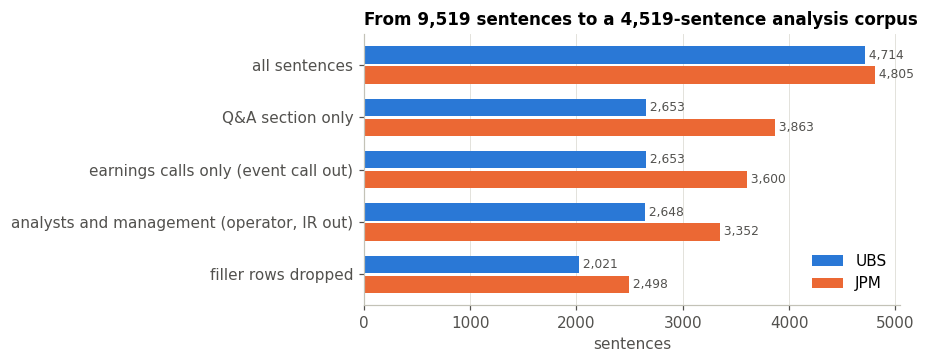

sentences  filler  filler_%
bank speaker_role                             
JPM  analyst            1125     448      39.8
     management         2227     406      18.2
UBS  analyst            1152     452      39.2
     management         1496     175      11.7

In [20]:
# 2.2 filter funnel with reasons, and the filler share by bank and role (N13)
fig, ax = plt.subplots(figsize=(8.5, 3.4))
y, h = np.arange(len(funnel)), 0.38
for i, b in enumerate(BANKS):
    ys = y + (i - 0.5) * h
    ax.barh(ys, funnel[b], height=h - 0.05, color=BANK_COLOR[b], label=b)
    for yy, v in zip(ys, funnel[b]):
        ax.text(v, yy, f" {v:,}", va="center", fontsize=8, color="#52514e")
ax.set_yticks(y, funnel.index)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("sentences")
ax.legend(loc="lower right")
ax.set_title(f"From {funnel['total'].iloc[0]:,} sentences to a "
             f"{funnel['total'].iloc[-1]:,}-sentence analysis corpus", loc="left")
plt.tight_layout()
plt.show()

filler_share = (pre.assign(filler_row=pre["filler"] != "")
                .groupby(["bank", "speaker_role"])["filler_row"].agg(sentences="size", filler="sum"))
filler_share["filler_%"] = (100 * filler_share["filler"] / filler_share["sentences"]).round(1)
display(filler_share)

> **Business view.** The funnel chart is ready for the team's data slide. The table under it shows that about 40% of analyst sentences at both banks are courtesy or very short lines, against 12% of UBS and 18% of JPMorgan management sentences. Analysts spend many words on greetings and framing, so without the filter their "topics" would be diluted by politeness, and raw sentence counts would overstate how much they actually ask.

c:\local_CAM\Emp_Proj\boe-financial-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


utterances  median_chars  median_tokens  over_MiniLM_pct  \
bank speaker_role                                                             
JPM  analyst              287         225.0           51.0              0.7   
     management           335         437.0          104.0             24.5   
UBS  analyst              194         229.5           56.0              5.7   
     management           169        1007.0          228.0             38.5   

                   over_mpnet_pct  qa_sentences_per_utterance  
bank speaker_role                                              
JPM  analyst                  0.0                         3.9  
     management               9.0                         6.6  
UBS  analyst                  0.0                         5.9  
     management              18.3                         8.9

clean sentences longer than the MiniLM limit: 0 of 4,519 (longest 172 word-pieces)


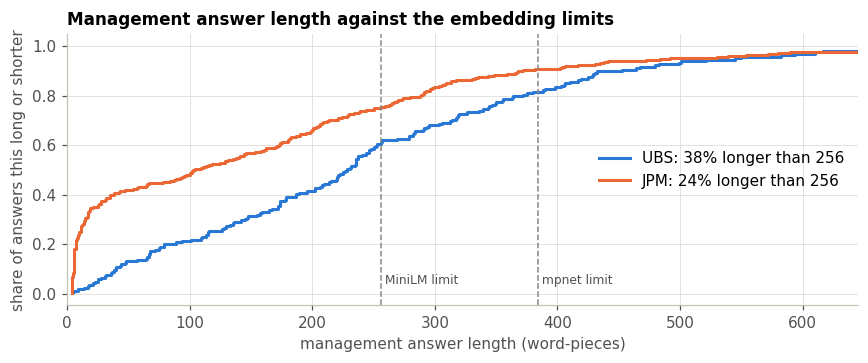

In [21]:
# 2.3 answer length in MiniLM word-pieces: how much of an answer an utterance-level embedding sees (N25)
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
tok.model_max_length = 1_000_000          # counting only, so no truncation warning
LIMITS = {"MiniLM": 256, "mpnet": 384}    # max_seq_length of the two sentence-transformers

def n_tokens(texts):
    return np.array([len(ids) for ids in tok(list(texts))["input_ids"]])

answers = utt[(utt["section"] == "qa") & (utt["call_type"] == "earnings")
              & utt["speaker_role"].isin(ROLES)].copy()
answers["tokens"] = n_tokens(answers["text"])
qa["tokens"] = n_tokens(qa["text"])

length = answers.groupby(["bank", "speaker_role"]).agg(
    utterances=("tokens", "size"),
    median_chars=("text_length", "median"),
    median_tokens=("tokens", "median"),
    over_MiniLM_pct=("tokens", lambda t: 100 * (t > LIMITS["MiniLM"]).mean()),
    over_mpnet_pct=("tokens", lambda t: 100 * (t > LIMITS["mpnet"]).mean()))
length["qa_sentences_per_utterance"] = (pre.groupby(["bank", "speaker_role", "turn_id"]).size()
                                        .groupby(["bank", "speaker_role"]).mean())
display(length.round(1))
print(f"clean sentences longer than the MiniLM limit: {(qa['tokens'] > LIMITS['MiniLM']).sum()} "
      f"of {len(qa):,} (longest {qa['tokens'].max()} word-pieces)")

fig, ax = plt.subplots(figsize=(8, 3.4))
mgmt = answers[answers["speaker_role"] == "management"]
for b in BANKS:
    t = np.sort(mgmt.loc[mgmt["bank"] == b, "tokens"].to_numpy())
    ax.step(t, np.arange(1, len(t) + 1) / len(t), where="post", color=BANK_COLOR[b],
            label=f"{b}: {100 * (t > LIMITS['MiniLM']).mean():.0f}% longer than {LIMITS['MiniLM']}")
for name, lim in LIMITS.items():
    ax.axvline(lim, color="#898781", lw=1, ls="--")
    ax.text(lim, 0.04, f" {name} limit", fontsize=8, color="#52514e")
ax.set_xlim(0, mgmt["tokens"].quantile(0.98))
ax.set_xlabel("management answer length (word-pieces)")
ax.set_ylabel("share of answers this long or shorter")
ax.set_title("Management answer length against the embedding limits", loc="left")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

> **Business view.** Embedding models can only read a limited amount of text at once (256 word-pieces for MiniLM, 384 for mpnet) and silently ignore the rest. UBS executives give much longer answers than JPMorgan's (median 228 word-pieces against 104), and 38% of UBS management answers are longer than MiniLM's limit, against 24% at JPMorgan. Had we embedded whole answers, the model would have missed the end of more than a third of UBS answers, and UBS would look different from JPMorgan partly because of length rather than content. Working sentence by sentence removes the problem: the longest clean sentence is 172 word-pieces, inside both limits. This is the main technical reason for the sentence-level design.

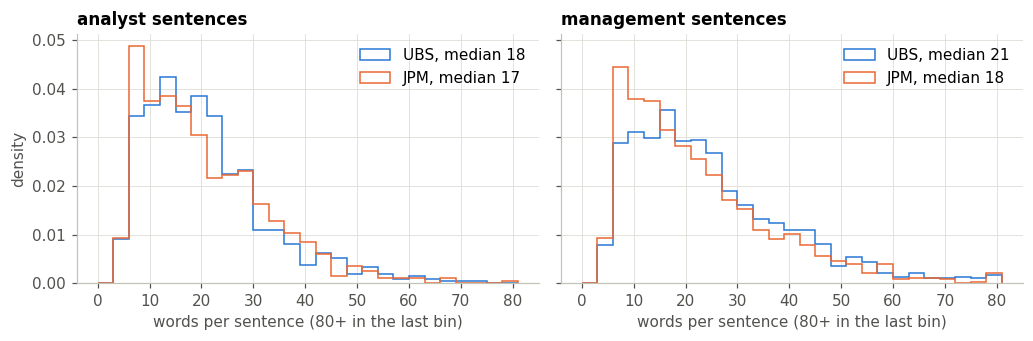

count  mean   std  min   50%   95%    max
bank speaker_role                                            
JPM  analyst        677.0  20.0  11.9  5.0  17.0  42.0   78.0
     management    1821.0  21.9  14.9  5.0  18.0  50.0  139.0
UBS  analyst        700.0  20.4  11.9  5.0  18.0  45.0   73.0
     management    1321.0  24.2  15.0  5.0  21.0  53.0  132.0

In [22]:
# 2.4 sentence length after cleaning, by bank and role
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
bins = np.arange(0, 82, 3)
for ax, role in zip(axes, ROLES):
    for b in BANKS:
        w = qa.loc[(qa["bank"] == b) & (qa["speaker_role"] == role), "n_words"]
        ax.hist(w.clip(upper=80), bins=bins, density=True, histtype="step", lw=2,
                color=BANK_COLOR[b], label=f"{b}, median {w.median():.0f}")
    ax.set_title(f"{role} sentences", loc="left")
    ax.set_xlabel("words per sentence (80+ in the last bin)")
    ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()
display(qa.groupby(["bank", "speaker_role"])["n_words"].describe(percentiles=[0.5, 0.95]).round(1))

> **Business view.** After cleaning, sentences from both banks have similar lengths (medians of 17 to 21 words, 95% under 55 words). Speaking style is comparable, so differences found later come from *what* is said, not from how long the sentences are. UBS management sentences are slightly longer (median 21 words against 18).

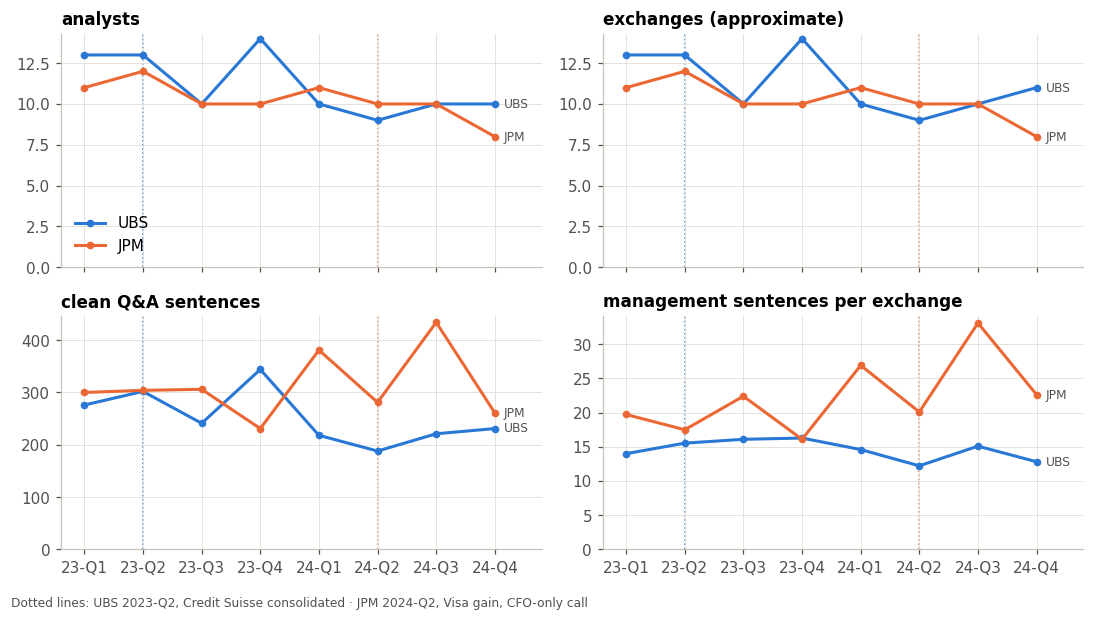

analysts     exchanges (approximate)       clean Q&A sentences       \
bank         JPM UBS                     JPM   UBS                 JPM  UBS   
quarter                                                                       
2023-Q1       11  13                    11.0  13.0                 300  276   
2023-Q2       12  13                    12.0  13.0                 304  302   
2023-Q3       10  10                    10.0  10.0                 306  241   
2023-Q4       10  14                    10.0  14.0                 231  344   
2024-Q1       11  10                    11.0  10.0                 381  218   
2024-Q2       10   9                    10.0   9.0                 281  188   
2024-Q3       10  10                    10.0  10.0                 434  221   
2024-Q4        8  10                     8.0  11.0                 261  231   

        management sentences      management sentences per exchange        
bank                     JPM  UBS                               JPM   UBS  
quarter                                                                    
2023-Q1                  217  182                              19.7  14.0  
2023-Q2                  210  202                              17.5  15.5  
2023-Q3                  224  161                              22.4  16.1  
2023-Q4                  161  228                              16.1  16.3  
2024-Q1                  296  146                              26.9  14.6  
2024-Q2                  201  110                              20.1  12.2  
2024-Q3                  331  151                              33.1  15.1  
2024-Q4                  181  141                              22.6  12.8

In [23]:
# 2.5 Q&A volume per earnings call: analysts, exchanges, and how much management says per exchange
turns = utt[(utt["section"] == "qa") & (utt["call_type"] == "earnings")]
by_call = ["bank", "quarter"]
volume = pd.DataFrame({
    "analysts": turns[turns["speaker_role"] == "analyst"].groupby(by_call)["speaker_name"].nunique(),
    "exchanges (approximate)": turns.groupby(by_call)["exchange"].max(),
    "clean Q&A sentences": qa.groupby(by_call).size(),
    "management sentences": qa[qa["speaker_role"] == "management"].groupby(by_call).size(),
})
volume["management sentences per exchange"] = (volume["management sentences"]
                                               / volume["exchanges (approximate)"])
panels = ["analysts", "exchanges (approximate)", "clean Q&A sentences", "management sentences per exchange"]
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
for ax, col in zip(axes.flat, panels):
    bank_lines(ax, volume[col], col)
    ax.set_ylim(bottom=0)
axes[0, 0].legend(loc="lower left")
fig.text(0.01, 0.005, BREAK_NOTE, fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()
display(volume.round(1).unstack("bank"))

> **Business view.** How much Q&A each call has. Both banks take questions from 8 to 14 analysts per call, roughly one exchange each. The difference is in the answers. JPMorgan management says 16 to 33 sentences per exchange, peaking in 2024-Q3, while UBS stays steady at 12 to 16. So JPMorgan answers at greater length, which is another reason the comparison works with per-sentence shares rather than totals.

In [24]:
# 2.6 who asks: analysts and houses per bank, and the houses on both banks' calls
an = utt[utt["speaker_role"] == "analyst"]
houses = an.groupby(["speaker_institution", "bank"])["speaker_name"].nunique().unstack(fill_value=0)
both = houses[(houses > 0).all(axis=1)]
people_both = set(an.loc[an["bank"] == "UBS", "speaker_name"]) & set(an.loc[an["bank"] == "JPM", "speaker_name"])
print(f"analysts: UBS {an.loc[an['bank'] == 'UBS', 'speaker_name'].nunique()}, "
      f"JPM {an.loc[an['bank'] == 'JPM', 'speaker_name'].nunique()}; "
      f"same person on both banks' calls: {sorted(people_both) or 'none'}")
print(f"houses on both banks' calls: {len(both)} of {len(houses)} (analysts per house)")
display(both)

analysts: UBS 18, JPM 16; same person on both banks' calls: none
houses on both banks' calls: 5 of 26 (analysts per house)


bank,JPM,UBS
speaker_institution,,
Autonomous Research,1,1
Bank of America,1,2
Deutsche Bank,1,1
Jefferies,1,1
Morgan Stanley,3,2


> **Business view.** Who asks the questions. UBS faces 18 analysts and JPMorgan 16, and no analyst appears on both banks' calls. Only 5 of 26 research houses (Autonomous, Bank of America, Deutsche Bank, Jefferies, Morgan Stanley) cover both. When the banks' Q&A differs, part of the reason may be that different people ask, not only that the banks differ. This is a caveat to state with every cross-bank finding.

In [25]:
# 2.7 keyword baseline for merger talk: the "before" for the semantic filter in Phase 4 (N20)
MERGER_KW = re.compile(r"(?i:credit suisse|first republic|\bintegrat\w*|\bacquisi\w*|\bmerger\w*)|\bCS\b|\bFRC\b")
qa["merger_keyword"] = qa["text"].str.contains(MERGER_KW)
kw = (qa.pivot_table(index="bank", columns="quarter", values="merger_keyword", aggfunc="sum")
        .reindex(columns=QUARTERS))
kw["total"] = kw.sum(axis=1)
kw["share_%"] = (100 * kw["total"] / qa.groupby("bank").size()).round(1)
display(kw)

quarter,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,total,share_%
bank,,,,,,,,,,
JPM,1,5,11,12,9,2,3,2,45,1.8
UBS,19,30,23,29,14,8,11,11,145,7.2


> **Business view.** A simple keyword count of merger talk ("Credit Suisse", "First Republic", "integration", "acquisition", "merger"). It finds 145 UBS sentences (7.2% of UBS Q&A) and 45 JPMorgan sentences (1.8%). UBS merger talk peaks in 2023-Q2 (30 sentences) and stays high through 2023, while JPMorgan's peaks later, in 2023-Q3 and Q4. This is the "before" baseline: the semantic method in Phase 4 has to beat it, because keywords miss sentences such as "the combined client book" that never name the deal.

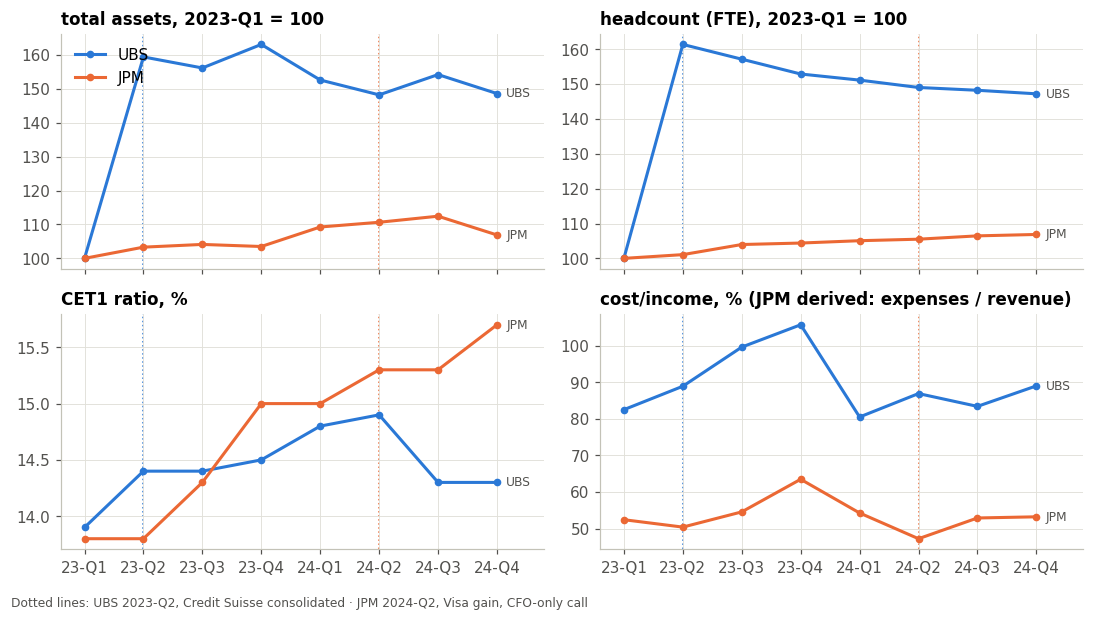

In [26]:
# 2.8 reported figures over time with breaks marked (JPM cost/income is derived, so labelled)
m = (metrics[metrics["basis"] == "reported"]
     .pivot_table(index=["bank", "quarter"], columns="metric_name", values="value"))
first = m.groupby(level="bank").transform("first")                     # 2023-Q1 values
series = {
    "total assets, 2023-Q1 = 100": 100 * m["total_assets"] / first["total_assets"],
    "headcount (FTE), 2023-Q1 = 100": 100 * m["personnel_fte"] / first["personnel_fte"],
    "CET1 ratio, %": m["cet1_ratio"],
    "cost/income, % (JPM derived: expenses / revenue)":
        m["cost_income_ratio"].fillna(100 * m["operating_expenses"] / m["total_revenues"]),
}
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
for ax, (title, s) in zip(axes.flat, series.items()):
    bank_lines(ax, s, title)
axes[0, 0].legend(loc="upper left")
fig.text(0.01, 0.005, BREAK_NOTE, fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

> **Business view.** The reported numbers behind the talk. UBS total assets and headcount jump by about 60% in 2023-Q2, when Credit Suisse was consolidated, then fall slowly as the integration cuts costs and runs down assets. JPMorgan grows gently. UBS's cost/income ratio passes 100% in 2023-Q4 (costs above revenue during integration) before settling at 80 to 90%; JPMorgan stays near 50 to 60%. Both banks raise their CET1 capital ratio, with JPMorgan ahead from 2023-Q4. This is the context for Phase 4: if UBS executives talk more about costs and restructuring, the financials show why.

### Summary

All 17 calls match the README counts. The two banks run their calls differently. UBS opens with long prepared remarks, JPMorgan's calls are mostly Q&A, and JPMorgan management says more per exchange (16 to 33 sentences against 12 to 16 at UBS). UBS executives give much longer single answers (median 228 word-pieces against 104), and 38% of them exceed MiniLM's 256 limit, which is why the analysis runs on sentences. Filler is about 40% of analyst sentences at both banks. No analyst covers both banks, and only 5 of 26 research houses do. Keyword search finds merger talk in 7.2% of UBS and 1.8% of JPMorgan Q&A sentences. The reported figures show the Credit Suisse step change in 2023-Q2 and UBS's cost/income above 100% in 2023-Q4.

**Business value.** This fills the team's missing EDA and sets the caveats for every comparison: compare shares rather than counts, mark the two break quarters, and remember that different analysts ask at each bank.

## Topic modelling on sentences

**Fidelity note.** Beyond C3: BERTopic runs on sentences rather than whole answers (N25), and topic prevalence is shown per bank and quarter instead of `topics_over_time`. This is a reference refit for Jack's track (N25 review), not a replacement for it.

In [27]:
# 3.1 sentence embeddings, computed once and cached next to the row keys they belong to (reused in Phase 4)
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {"MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
          "mpnet": "sentence-transformers/all-mpnet-base-v2"}

def embed(tag, texts, keys, batch_size=64):
    path, key_path = OUT / f"emb_qa_{tag}.npy", OUT / f"emb_qa_{tag}_keys.csv"
    if path.exists() and key_path.exists() and pd.read_csv(key_path)["key"].tolist() == list(keys):
        print(f"{tag}: loaded from {path.name}")
        return np.load(path)
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    t0 = time.time()
    E = model.encode(list(texts), batch_size=batch_size, normalize_embeddings=True,
                     convert_to_numpy=True, show_progress_bar=True)
    print(f"{tag}: {E.shape[0]:,} x {E.shape[1]} in {time.time() - t0:.0f}s on {DEVICE}, "
          f"max_seq_length {model.max_seq_length}")
    np.save(path, E)
    pd.Series(list(keys), name="key").to_csv(key_path, index=False)
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return E

emb = {"MiniLM": embed("MiniLM", qa["text"], qa["key"])}

MiniLM: loaded from emb_qa_MiniLM.npy


> **Business view.** Turns each of the 4,519 sentences into a list of 384 numbers (an embedding) that captures its meaning, so sentences about the same subject sit close together even when they use different words. It took 4 seconds on the laptop GPU. The result is saved and reused in Phase 4, so this step only runs once.

In [28]:
# 3.2 BERTopic on the clean Q&A sentences of both banks: one topic space, so shares compare directly
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

MIN_TOPIC = 15
topic_model = BERTopic(
    embedding_model=MODELS["MiniLM"],
    umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=SEED),
    hdbscan_model=HDBSCAN(min_cluster_size=MIN_TOPIC, min_samples=5, metric="euclidean",
                          cluster_selection_method="eom", prediction_data=True),
    vectorizer_model=CountVectorizer(stop_words=STOP_WORDS, ngram_range=(1, 2), min_df=3),
    top_n_words=10,
)
t0 = time.time()
topics, _ = topic_model.fit_transform(qa["text"].tolist(), embeddings=emb["MiniLM"])
qa["topic"] = topics
print(f"fitted in {time.time() - t0:.0f}s")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10691.02it/s]


fitted in 25s


> **Business view.** BERTopic groups sentences with similar meaning into topics automatically, without us choosing the topics in advance. Both banks are fitted together, so a topic means the same thing for UBS and JPMorgan and their shares can be compared directly. A topic needs at least 15 sentences, so one-off clusters are not counted as topics.

In [29]:
# 3.3 before-and-after figures for the fine-tuning slide: pilot (R9), John's first iteration (R16), this refit
info = topic_model.get_topic_info()
found = info.loc[info["Topic"] >= 0, "Topic"].tolist()
top_words = {t: [w for w, _ in topic_model.get_topic(t)][:10] for t in found}
diversity = len({w for ws in top_words.values() for w in ws}) / (10 * len(found))
name_hits = sum(any(p in NAMES for p in w.split()) for ws in top_words.values() for w in ws)
run_log = pd.DataFrame([
    {"run": "pilot, 20 Sep (R9)", "unit": "utterance", "topics": "67", "outliers_%": "not recorded",
     "diversity": "not recorded", "name words in top-10": "most topics"},
    {"run": "John, first iteration (R16)", "unit": "utterance", "topics": "12 analyst, ~20 management",
     "outliers_%": "11 / 14", "diversity": "not recorded", "name words in top-10": "not recorded"},
    {"run": "this refit", "unit": "sentence", "topics": str(len(found)),
     "outliers_%": f"{100 * (qa['topic'] == -1).mean():.1f}", "diversity": f"{diversity:.2f}",
     "name words in top-10": str(name_hits)},
]).set_index("run")
display(run_log)
run_log.to_csv(OUT / "topic_runs.csv")

,unit,topics,outliers_%,diversity,name words in top-10
run,,,,,
"pilot, 20 Sep (R9)",utterance,67,not recorded,not recorded,most topics
"John, first iteration (R16)",utterance,"12 analyst, ~20 management",11 / 14,not recorded,not recorded
this refit,sentence,76,34.8,0.83,0


> **Business view.** A before-and-after table for the team's optimisation slide. The pilot on whole answers gave 67 topics, most labelled with executives' names. This sentence-level refit gives 76 topics with a diversity of 0.83 (few words repeat across topics, so topics are distinct) and no names in the labels. The cost is that 34.8% of sentences stay unassigned (outliers), which is common for short sentences. A CPU test run gave 77 topics and 31.9% outliers: GPU arithmetic shifts the clustering slightly, so topic numbers must be read from the saved file, not from a rerun.

In [30]:
# 3.4 topics: size, top words, and lean to one bank (share of each bank's sentences, 50 = even, 100 = UBS only)
counts = pd.crosstab(qa["topic"], qa["bank"])
rate = counts / counts.sum()
topic_table = pd.DataFrame({
    "sentences": counts.sum(axis=1),
    "UBS_lean": (100 * rate["UBS"] / rate.sum(axis=1)).round(0),
    "analyst_%": (100 * pd.crosstab(qa["topic"], qa["speaker_role"], normalize="index")["analyst"]).round(0),
    "top words": pd.Series({t: ", ".join(ws[:6]) for t, ws in top_words.items()}),
}).drop(index=-1, errors="ignore").sort_values("sentences", ascending=False)
pd.set_option("display.max_colwidth", 90)
display(topic_table.head(30))

,sentences,UBS_lean,analyst_%,top words
0,179,43.0,39.0,"capital, deploy, capital requirements, excess capital, excess, requirements"
1,123,36.0,48.0,"nii, ex, nii guidance, guidance, revenue, curve"
2,116,47.0,38.0,"deposit, deposits, sweep, deposit mix, betas, balances"
3,114,64.0,8.0,"plan, proposal, need, focused, takes, clarity"
4,93,54.0,47.0,"billion, exit, billion billion, 10 billion, million, exit rate"
5,93,23.0,33.0,"banks, banking, bank, investment, investment banking, commercial"
6,87,76.0,34.0,"2025, 2024, teens, mid, 2026, 2027"
7,80,32.0,15.0,"outcome, happen, speculate, difficult, model, happens"
8,75,72.0,20.0,"clients, client, segments, client segments, services, segment"
9,75,28.0,32.0,"rates, rate, recession, higher, fed, cuts"


> **Business view.** The 30 largest topics, with a lean score (50 = both banks equally, 100 = UBS only, 0 = JPMorgan only) and the share asked by analysts. Some topics belong to one bank: Credit Suisse (97), Switzerland and market share (100) and non-core legacy wind-down (100) are UBS; loans and mortgages (18) and headwinds and pressure (17) lean to JPMorgan. Capital, NII guidance and deposits are shared. Topic 7 (32, 85% management) is mostly JPMorgan executives declining to forecast. Topics 3 ("plan, proposal"), 12 ("let, second, answer"), 18 and 25 are procedural language rather than business themes, and are the first candidates to remove when the model is tuned.

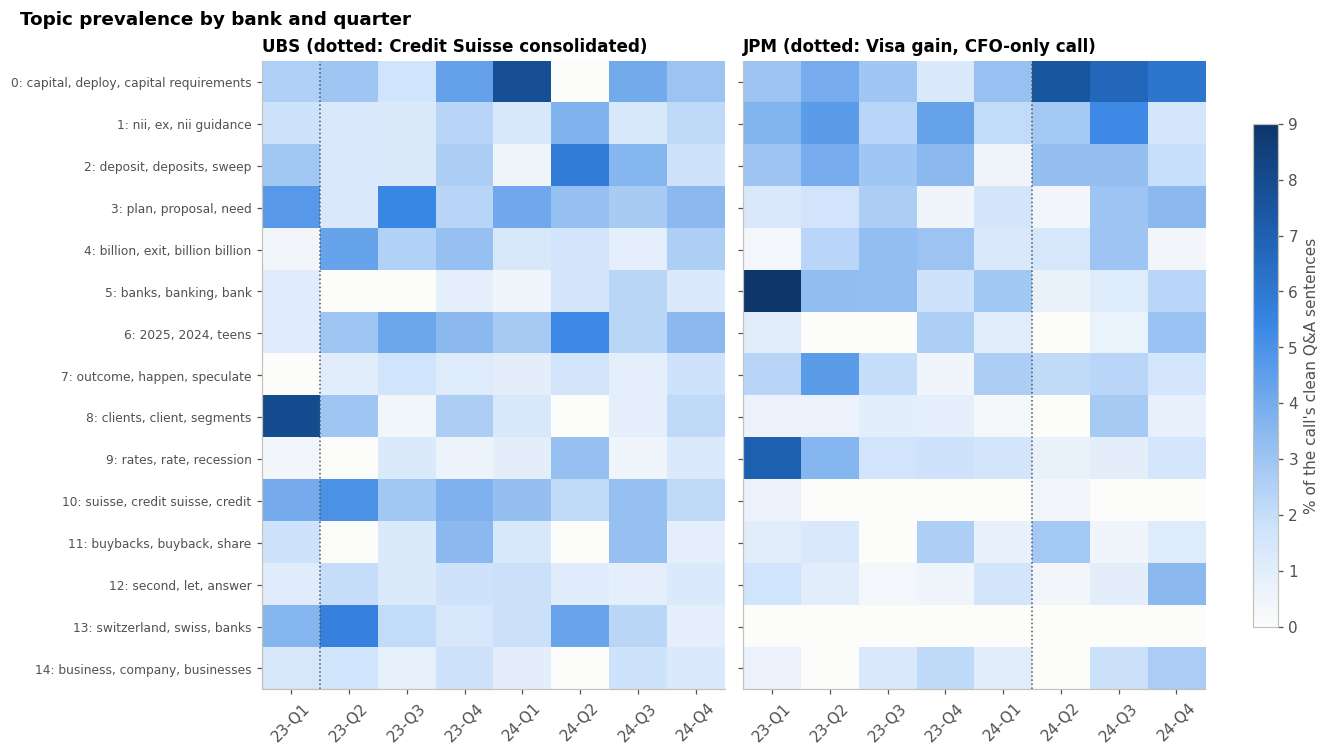

In [31]:
# 3.5 topic prevalence per bank and quarter: share of each call's clean Q&A sentences (outliers in the base)
TOP_K = 15
top = topic_table.index[:TOP_K].tolist()
share = pd.crosstab(qa["topic"], [qa["bank"], qa["quarter"]], normalize="columns")
vmax = 100 * share.loc[top].to_numpy().max()
fig, axes = plt.subplots(1, 2, figsize=(12, 0.33 * TOP_K + 1.8), sharey=True, layout="constrained")
for ax, b in zip(axes, BANKS):
    mat = 100 * share.loc[top, b].reindex(columns=QUARTERS)
    im = ax.imshow(mat.to_numpy(), aspect="auto", cmap=BLUES, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(QUARTERS)), QLABELS, rotation=45)
    ax.grid(False)
    ax.axvline(QUARTERS.index(BREAKS[b][0]) - 0.5, color="#52514e", lw=1, ls=":")
    ax.set_title(f"{b} (dotted: {BREAKS[b][1]})", loc="left")
axes[0].set_yticks(range(len(top)), [f"{t}: {', '.join(top_words[t][:3])}" for t in top], fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.8, label="% of the call's clean Q&A sentences")
fig.suptitle("Topic prevalence by bank and quarter", x=0.01, ha="left", fontweight="bold")
plt.show()

> **Business view.** How much of each call is spent on each topic (darker = more). The pattern follows real events. UBS 2023-Q1, days after the rescue, is dominated by clients (topic 8: keeping and winning back Credit Suisse clients), and Credit Suisse and the Swiss market (10, 13) stay visible into 2024. JPMorgan 2023-Q1, during the US regional bank failures, is dominated by the banking sector and rates (5, 9). From 2024-Q2 JPMorgan's Q&A shifts to capital (topic 0: excess capital, deployment). That the topics move with the news is evidence the method picks up real information, which is the Bank's first business question.

In [32]:
# 3.6 five sentences nearest each topic's centre, for naming by a finance reader (Step 3.5).
# Prints transcript text: clear outputs before committing.
E = emb["MiniLM"]
topic_arr = qa["topic"].to_numpy()
for t in top:
    idx = np.flatnonzero(topic_arr == t)
    nearest = idx[np.argsort(-(E[idx] @ E[idx].mean(axis=0)))[:5]]
    print(f"\ntopic {t} · {len(idx)} sentences · {', '.join(top_words[t][:6])}")
    for i in nearest:
        print(f"   {qa.at[i, 'bank']} {qa.at[i, 'quarter']} {qa.at[i, 'speaker_role'][:4]}  {qa.at[i, 'text'][:170]}")

qa[["key", "sentence_id", "topic"]].to_csv(OUT / "topics_sentence_MiniLM.csv", index=False)


topic 0 · 179 sentences · capital, deploy, capital requirements, excess capital, excess, requirements
   JPM 2024-Q2 mana  So, given all that, putting it all together, and sorry for the long answer, we remain comfortable with the current amount of excess capital.
   JPM 2024-Q3 mana  We're can always deploy more capital if we want.
   JPM 2024-Q1 mana  And as Jamie says, the capital is earnings in store, and right now we don't see a lot of really compelling opportunities to deploy the capital.
   JPM 2024-Q1 mana  I urge all the analysts to keep in mind, excess capital is not wasted capital, it's earnings in store.
   UBS 2023-Q3 mana  And this will be in conflict with capital accretion and the ability for us to return capital to shareholders.

topic 1 · 123 sentences · nii, ex, nii guidance, guidance, revenue, curve
   JPM 2023-Q2 anal  And then secondly, and probably more importantly, can you help us think about the implications of higher-for-longer rates on the outlook for NII next

> **Business view.** For each of the 15 largest topics, the five sentences closest to the topic's centre. Word lists can mislead; real sentences show what a topic is about, and they are the input for naming the topics with a finance reader. Topic 7, for example, turns out to be JPMorgan management declining to forecast ("we are not predicting when", "we don't really know what's going to happen"), which its word list ("outcome, happen, speculate") only hints at. The topic of every sentence is saved for joining with Jack's track later (step 4.9).

### Summary

A sentence-level BERTopic refit on both banks' Q&A (MiniLM, minimum topic size 15) finds 76 topics, leaves 34.8% of sentences as outliers, has a diversity of 0.83 and no speaker names among the top words. The utterance-level pilot had 67 topics, mostly labelled by names. A CPU test gave 77 topics and 31.9% outliers, so GPU and CPU runs differ slightly and the saved `topics_sentence_MiniLM.csv` is the record.

Provisional topic names, until the finance reader agrees them: capital deployment (0), NII guidance (1), deposits (2), dollar targets and exit rates (4), the banking sector (5), multi-year guidance (6), declining to forecast (7), clients (8), rates and recession (9), Credit Suisse (10), buybacks (11), Swiss market (13). Topics 3, 12, 18 and 25 are procedural. Several topics lean strongly to one bank (Credit Suisse, Switzerland and non-core to UBS; loans and headwinds to JPMorgan), and topic shares move with events: the 2023 US bank failures at JPMorgan, the Credit Suisse client question at UBS, and capital at JPMorgan from 2024-Q2.

**Business value.** Unsupervised topics already separate the two banks' agendas and follow the news, which partly answers the Bank's first business question. This is a reference for Jack's topic track, not a replacement. Next tuning step: a longer stop list (`let`, `add`, `answer`, `asking`, `need`, `doing`) and a check of the minimum topic size.

## Cross-bank comparison

In [33]:
# 4.1 corpus for the comparison: clean Q&A sentences, both banks on the same per-sentence footing
display(qa.pivot_table(index=["bank", "speaker_role"], columns="stage_group", values="key",
                       aggfunc="count", margins=True).reindex(columns=STAGE_GROUPS + ["All"]))

stage_group        early  closing  integration   All
bank speaker_role                                   
JPM  analyst          83       94          500   677
     management      217      210         1394  1821
UBS  analyst          94      100          506   700
     management      182      202          937  1321
All                  576      606         3337  4519

> **Business view.** The comparison corpus by bank, role and deal stage. Most sentences (3,337 of 4,519) fall in the integration period, because six of the eight quarters come after the deals closed. The early and closing stages have about 80 to 100 analyst and 180 to 220 management sentences per bank: enough for shares, but with wider uncertainty. That is why the gold set below samples every group equally.

In [34]:
# 4.2 second embedding model for the comparison (MiniLM is cached from 3.1)
emb["mpnet"] = embed("mpnet", qa["text"], qa["key"], batch_size=32)
for tag, E in emb.items():
    norms = np.linalg.norm(E, axis=1)
    print(f"{tag:7s} {E.shape[0]:,} x {E.shape[1]}   norms {norms.min():.3f} to {norms.max():.3f}")

mpnet: loaded from emb_qa_mpnet.npy
MiniLM  4,519 x 384   norms 1.000 to 1.000
mpnet   4,519 x 768   norms 1.000 to 1.000


> **Business view.** Embeds the same sentences with a second, larger model (mpnet, 768 numbers per sentence, 27 seconds on the GPU). With two models we can test whether a finding is real or a quirk of one model: when both agree, the finding is more trustworthy. The norms of 1.000 confirm both are normalised, so their similarity scores are on the same scale.

### Theme codebook (anchors and gold labels)

| Label | Theme | A sentence belongs here when it is mainly about |
|---|---|---|
| `integration` | Integration and M&A | the 2023 acquisition, integration progress and milestones, client or system migration, legal-entity mergers, deal accounting |
| `restructuring` | Restructuring | winding down legacy or non-core books, exiting businesses, reorganisation, restructuring charges |
| `capital` | Capital and liquidity | capital ratios and requirements, buybacks and dividends, RWA and leverage, liquidity, funding, deposit outflows |
| `risk` | Risk and credit quality | credit losses and reserves, loan quality, real-estate exposure, market and rate risk, litigation |
| `costs` | Costs and efficiency | expenses, cost savings, cost/income, headcount, investment spend |
| `revenue` | Revenue and outlook | net interest income and deposit pricing, fees, trading, wealth flows, guidance, client activity |
| `other` | Other | none of the above, or procedure |

One theme per sentence (the main one), judged from the sentence alone. `sentiment` is the speaker's tone about the bank's business: `positive`, `neutral` or `negative`. `merger_related` is `yes` when the sentence is about either bank's 2023 acquisition or its integration, otherwise `no`. Here the codebook is applied by a local LLM (`phi4-mini` through Ollama) instead of by hand (step 4.4b, option C). The tagger is then scored against the LLM's labels, so every score is agreement with an LLM reference, not accuracy checked by people.

In [35]:
# 4.3 theme anchors v1: five bank-neutral descriptions per theme (N20: no bank names)
ANCHORS_V1 = {
    "integration": [
        "The integration of the acquired bank is progressing well and we remain on track with our milestones.",
        "We are migrating the acquired clients and accounts onto our own platforms and systems.",
        "The merger of the two legal entities was completed after the transaction closed.",
        "Purchase accounting, negative goodwill and other acquisition-related effects from the deal.",
        "How is the combination of the two businesses going, and what are the remaining integration risks?",
    ],
    "restructuring": [
        "We continue to wind down the legacy portfolio and exit businesses that do not fit our strategy.",
        "Running off non-core positions released risk-weighted assets and reduced the balance sheet.",
        "The reorganisation involves closing overlapping units and simplifying the group structure.",
        "Restructuring charges and exit costs were higher this quarter.",
        "How much longer will it take to wind down the remaining legacy book?",
    ],
    "capital": [
        "Our CET1 capital ratio remains well above the regulatory requirement.",
        "We intend to return excess capital to shareholders through share buybacks and dividends.",
        "The proposed capital rules and Basel III requirements would increase the capital we need to hold.",
        "Liquidity and funding remain strong, with a comfortable liquidity coverage ratio.",
        "Risk-weighted assets and the leverage ratio determine how much balance sheet we can deploy.",
    ],
    "risk": [
        "Credit quality remains solid, but we expect net charge-offs to normalise from low levels.",
        "We added to our loan loss reserves because the macroeconomic outlook weakened.",
        "Exposure to commercial real estate and office loans is an area we are watching closely.",
        "Litigation, legal provisions and regulatory investigations remain a risk to earnings.",
        "Market volatility and geopolitical uncertainty could affect the portfolio.",
    ],
    "costs": [
        "We are on track to deliver the planned gross cost savings.",
        "Expenses rose this quarter, driven by investment in technology and higher compensation.",
        "Our cost-to-income ratio should improve as the efficiency measures come through.",
        "We reduced headcount and contractor spend to bring the cost base down.",
        "What is your expense guidance for next year?",
    ],
    "revenue": [
        "Net interest income will come down as deposit costs rise and balances move to higher-yielding products.",
        "Investment banking fees and markets revenue were strong compared with last year.",
        "Wealth management attracted net new assets and fee income grew.",
        "Our outlook assumes modest loan growth and a few rate cuts next year.",
        "Client activity and consumer spending remain healthy.",
    ],
}
THEMES = list(ANCHORS_V1) + ["other"]
THRESH_V1 = 0.30          # provisional: below it a sentence is "other"; tuned on the gold set in 4.5
BANK_NAMES = re.compile(r"\b(?:ubs|jp ?morgan|chase|credit suisse|first republic|swiss|switzerland)\b", re.I)
assert not any(BANK_NAMES.search(a) for v in ANCHORS_V1.values() for a in v), "an anchor names a bank"

def theme_scores(tag, anchors):
    # cosine similarity of every sentence to each theme's anchor centroid
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    centroids = []
    for texts in anchors.values():
        c = model.encode(texts, normalize_embeddings=True, convert_to_numpy=True).mean(axis=0)
        centroids.append(c / np.linalg.norm(c))
    del model
    return pd.DataFrame(emb[tag] @ np.vstack(centroids).T, columns=list(anchors))

def assign(scores, threshold):
    return scores.idxmax(axis=1).where(scores.max(axis=1) >= threshold, "other")

scores_v1 = {tag: theme_scores(tag, ANCHORS_V1) for tag in emb}
for tag, S in scores_v1.items():
    qa[f"theme_v1_{tag}"] = assign(S, THRESH_V1).to_numpy()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9894.57it/s]


> **Business view.** This is how each sentence gets a business theme. For each of the six themes the Bank cares about (integration and M&A, restructuring, capital and liquidity, risk, costs, revenue), we wrote five short example sentences, the "anchors". A sentence takes the theme whose anchors it is most similar to, or "other" if no theme is close enough (similarity below 0.30). The anchors never name a bank, and an automatic check enforces this, so the same yardstick is applied to UBS and JPMorgan. Unlike the BERTopic topics, these themes are fixed in advance and match the Bank's own questions.

In [36]:
# 4.3 diagnostics: best-theme similarity, share left as "other" at several thresholds, v1 theme shares
from sklearn.metrics import cohen_kappa_score

rows = []
for tag, S in scores_v1.items():
    best = S.max(axis=1)
    rows.append({"model": tag,
                 **{f"p{int(100 * q)}": round(best.quantile(q), 3) for q in (0.05, 0.25, 0.5, 0.75, 0.95)},
                 **{f"other_% at {t:.2f}": round(100 * (best < t).mean(), 1) for t in (0.20, 0.25, 0.30, 0.35, 0.40)}})
display(pd.DataFrame(rows).set_index("model"))

shares = pd.concat({tag: pd.crosstab(qa[f"theme_v1_{tag}"], qa["bank"], normalize="columns").mul(100).round(1)
                    for tag in emb}, axis=1).reindex(THEMES)
display(shares)
print(f"MiniLM and mpnet give the same theme for "
      f"{100 * (qa['theme_v1_MiniLM'] == qa['theme_v1_mpnet']).mean():.0f}% of sentences "
      f"(kappa {cohen_kappa_score(qa['theme_v1_MiniLM'], qa['theme_v1_mpnet']):.2f})")

print("\nmerger keywords (2.7) against the v1 integration theme, MiniLM")
display(pd.crosstab([qa["bank"], qa["merger_keyword"]], qa["theme_v1_MiniLM"].eq("integration")
                    .rename("integration theme"), margins=True))

,p5,p25,p50,p75,p95,other_% at 0.20,other_% at 0.25,other_% at 0.30,other_% at 0.35,other_% at 0.40
model,,,,,,,,,,
MiniLM,0.111,0.246,0.372,0.471,0.566,17.7,25.4,35.1,44.9,56.8
mpnet,0.103,0.240,0.361,0.446,0.551,18.2,26.6,36.2,47.6,61.7


MiniLM       mpnet      
bank             JPM   UBS   JPM   UBS
integration      3.2   6.9   3.4   8.6
restructuring    4.2   9.2   1.8   6.4
capital         12.1  15.7  15.6  16.1
risk            15.9   8.7  18.5  11.8
costs            6.1  12.3   6.6  15.0
revenue         20.7  15.5  14.2  10.3
other           37.8  31.8  39.8  31.8

MiniLM and mpnet give the same theme for 64% of sentences (kappa 0.55)

merger keywords (2.7) against the v1 integration theme, MiniLM


integration theme    False  True   All
bank merger_keyword                   
JPM  False            2382    71  2453
     True               37     8    45
UBS  False            1779    97  1876
     True              102    43   145
All                   4300   219  4519

> **Business view.** First results, before any tuning. At the 0.30 cut-off about 35% of sentences are "other"; the first table shows how that share moves with the cut-off (18% at 0.20, 57% at 0.40), so the cut-off is the main setting to tune on the gold set. In the theme shares, UBS spends more of its Q&A on integration (6.9% against 3.2%), restructuring (9.2% against 4.2%) and costs (12.3% against 6.1%), while JPMorgan spends more on risk (15.9% against 8.7%) and revenue (20.7% against 15.5%). Both models point the same way for every theme, which fits a bank absorbing a failed rival against one running business as usual. But the two models give the same theme to only 64% of sentences (kappa 0.55, moderate), so the model choice has to be settled on the gold set. The last table shows that the keywords and the integration theme overlap only partly (43 of 145 UBS keyword sentences): each finds sentences the other misses, and only human labels can say which is right.

In [37]:
# 4.3 check by eye: strongest and borderline sentences per theme (MiniLM v1).
# Prints transcript text: clear outputs before committing.
S, labels = scores_v1["MiniLM"], qa["theme_v1_MiniLM"].to_numpy()
for theme in ANCHORS_V1:
    idx = np.flatnonzero(labels == theme)
    order = idx[np.argsort(-S[theme].to_numpy()[idx])]
    print(f"\n{theme}: {len(idx)} sentences")
    for kind, picks in (("top ", order[:3]), ("edge", order[-3:])):
        for i in picks:
            print(f"   {kind} {S.at[i, theme]:.2f} {qa.at[i, 'bank']}  {qa.at[i, 'text'][:150]}")


integration: 219 sentences
   top  0.66 UBS  So, well, first of all, on the integration, of course, you know, now that we go through, as I mentioned, it's very important to understand the sequenc
   top  0.65 UBS  In terms of the acquired – you were asking business exits and the revenue attached.
   top  0.62 UBS  I'm convinced that a lot of the clients will see the value added of the combined businesses and some of those flows will revert.
   edge 0.31 UBS  And probably what I can offer as a comment is that as time goes by we saw it already in the second quarter of the year after the announcement of the t
   edge 0.30 UBS  In terms of your second question on the national charter and the timing, look, we're working on moving forward with getting the application in.
   edge 0.30 UBS  So, two examples where, and for different reasons of what excites us in terms of the acquisition.

restructuring: 291 sentences
   top  0.61 UBS  In terms of the restructuring you asked about, we'll come b

> **Business view.** A human sanity check: the three strongest and three weakest sentences for each theme. The strongest ones fit well ("we remain comfortable with the current amount of excess capital" is capital). The weakest, just above 0.30, are often wrong: "If I'm here for several more years, and I may or may not be Chairman" is tagged capital, and "And so, we calculate as such" is tagged costs. So the 0.30 cut-off is too loose at the edges, and these examples are concrete targets for the second version of the anchors.

In [38]:
# 4.4 gold set: 10 sentences per bank x role x stage group (120), split 60% tune / 40% test.
# Once gold_key.csv exists it is loaded, never redrawn, so labels stay attached to their sentences.
STRATA = ["bank", "speaker_role", "stage_group"]
key_path = OUT / "gold_key.csv"
if key_path.exists():
    gold = pd.read_csv(key_path)
    print(f"gold set loaded from {key_path.name}")
else:
    gold = (qa.groupby(STRATA).sample(n=10, random_state=SEED)
              [["key", "sentence_id"] + STRATA + ["quarter", "text"]]
              .sample(frac=1, random_state=SEED).reset_index(drop=True))
    gold.insert(0, "gold_id", [f"G{i:03d}" for i in range(1, len(gold) + 1)])
    gold["split"] = "tune"
    rng = np.random.default_rng(SEED)
    for _, g in gold.groupby(STRATA):
        gold.loc[rng.choice(g.index, size=4, replace=False), "split"] = "test"
    gold.to_csv(key_path, index=False)
    print(f"wrote {key_path.name}")
missing = set(gold["key"]) - set(qa["key"])
assert not missing, f"{len(missing)} gold sentences are no longer in the corpus"
display(gold.pivot_table(index=["bank", "speaker_role"], columns=["stage_group", "split"],
                         values="gold_id", aggfunc="count"))

gold set loaded from gold_key.csv


stage_group       closing      early      integration     
split                test tune  test tune        test tune
bank speaker_role                                         
JPM  analyst            4    6     4    6           4    6
     management         4    6     4    6           4    6
UBS  analyst            4    6     4    6           4    6
     management         4    6     4    6           4    6

> **Business view.** Draws the "gold set": 120 real sentences, 10 from each mix of bank (2) × speaker role (2) × deal stage (3). The next cell gives each one reference labels, the answer key used to grade the automatic theme tagger. 72 sentences are used to tune the method (cut-off, anchor wording, model) and 48 are held back for the final score, so the method is not graded on the sentences it was tuned on. The draw is saved once and never redrawn, so labels always stay attached to the same sentences.

In [39]:
# 4.4b reference labels from a local LLM (phi4-mini through Ollama) instead of human labellers (option C, D45).
# Prompt v2: v1 opened with the two 2023 deals, which pushed vague sentences into integration (R25). v2 names
# the deals only in the merger question and sends sentences with no clear topic to other.
# The model sees only the sentence and the codebook, never the bank or the speaker. Each sentence is labelled
# twice, with the theme list in codebook order and then reversed; the second pass only measures stability.
# Progress is saved after every answer, and the finished file is never overwritten, so the model runs once.
import json, urllib.request
from tqdm.auto import tqdm

LLM, PROMPT, OLLAMA = "phi4-mini", "v2", "http://localhost:11434"
LABELS = ["theme", "sentiment", "merger_related"]
ALLOWED = {"theme": THEMES, "sentiment": ["positive", "neutral", "negative"], "merger_related": ["yes", "no"]}
CODEBOOK = {   # the theme codebook above, word for word
    "integration": "the 2023 acquisition, integration progress and milestones, client or system migration, "
                   "legal-entity mergers, deal accounting",
    "restructuring": "winding down legacy or non-core books, exiting businesses, reorganisation, restructuring charges",
    "capital": "capital ratios and requirements, buybacks and dividends, RWA and leverage, liquidity, funding, "
               "deposit outflows",
    "risk": "credit losses and reserves, loan quality, real-estate exposure, market and rate risk, litigation",
    "costs": "expenses, cost savings, cost/income, headcount, investment spend",
    "revenue": "net interest income and deposit pricing, fees, trading, wealth flows, guidance, client activity",
    "other": "none of the above, or procedure",
}
assert list(CODEBOOK) == THEMES

def ollama(endpoint, body, timeout=300):
    req = urllib.request.Request(f"{OLLAMA}/api/{endpoint}", json.dumps(body).encode(),
                                 {"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read())

def llm_label(sentence, order):
    prompt = ("You label one sentence from the Q&A of a bank's quarterly earnings call.\n"
              "Use only what the sentence itself says. Do not guess what the wider call was about.\n\n"
              "theme: the one theme the sentence is mainly about.\n"
              + "\n".join(f"- {t}: {CODEBOOK[t]}" for t in order) + "\n"
              "If the sentence has no clear business topic of its own (a greeting, thanks, who answers which "
              "question, or a vague remark), the theme is other.\n\n"
              "sentiment: the speaker's tone about the bank's business: positive, neutral or negative.\n\n"
              "merger_related: yes only if the sentence itself refers to a 2023 acquisition (UBS acquiring "
              "Credit Suisse, or JPMorgan acquiring First Republic), the acquired bank, or combining the two "
              "banks (integration, migration, synergies, legal-entity mergers); otherwise no.\n\n"
              f"Sentence: {sentence}")
    schema = {"type": "object", "required": LABELS, "properties": {   # answers can only be codebook values
        "theme": {"type": "string", "enum": list(order)},
        "sentiment": {"type": "string", "enum": ALLOWED["sentiment"]},
        "merger_related": {"type": "string", "enum": ALLOWED["merger_related"]}}}
    reply = ollama("chat", {"model": LLM, "stream": False, "format": schema, "keep_alive": "5m",
                            "options": {"temperature": 0, "seed": SEED, "num_ctx": 2048, "num_predict": 60},
                            "messages": [{"role": "user", "content": prompt}]})
    return json.loads(reply["message"]["content"])

llm_path = OUT / f"gold_labels_llm_{LLM.replace('-', '')}_{PROMPT}.csv"
if llm_path.exists():
    llm = pd.read_csv(llm_path)
    print(f"LLM labels loaded from {llm_path.name}")
else:
    try:
        installed = [m["name"] for m in json.loads(urllib.request.urlopen(f"{OLLAMA}/api/tags", timeout=5).read())["models"]]
    except OSError as e:
        raise RuntimeError("Ollama is not running: start the Ollama app, then run this cell again") from e
    if not any(m.split(":")[0] == LLM for m in installed):
        raise RuntimeError(f"{LLM} is not installed: run `ollama pull {LLM}` in a terminal")
    if DEVICE == "cuda":
        torch.cuda.empty_cache()   # leave the GPU to the LLM (C3 lesson)
    partial = OUT / f"{llm_path.stem}.partial.jsonl"
    done = [json.loads(l) for l in partial.read_text(encoding="utf-8").splitlines()] if partial.exists() else []
    seen = {(r["gold_id"], r["pass"]) for r in done}
    t0 = time.time()
    with partial.open("a", encoding="utf-8") as f:
        for pass_name, order in (("codebook", THEMES), ("reversed", THEMES[::-1])):
            todo = [(g, t) for g, t in zip(gold["gold_id"], gold["text"]) if (g, pass_name) not in seen]
            for gid, text in tqdm(todo, desc=f"{LLM}, {pass_name} order"):
                row = {"gold_id": gid, "pass": pass_name, **llm_label(text, order)}
                f.write(json.dumps(row) + "\n")
                f.flush()
                done.append(row)
    ollama("generate", {"model": LLM, "keep_alive": 0, "stream": False})   # unload the model from the GPU
    llm = pd.DataFrame(done)[["gold_id", "pass"] + LABELS]
    llm.to_csv(llm_path, index=False)
    partial.unlink()
    print(f"wrote {llm_path.name}: {len(llm)} labels, {(time.time() - t0) / 60:.1f} min this run")

LLM labels loaded from gold_labels_llm_phi4mini_v2.csv


> **Business view.** Instead of people hand-labelling the answer key, a small AI model running on the laptop (`phi4-mini`) labels the 120 sentences: theme, tone, and whether the sentence is about one of the 2023 acquisitions. No text leaves the laptop, which matters for a regulator handling sensitive material. Each sentence is labelled twice, with the theme list in a different order, to test whether the answers are stable. The first set of instructions (prompt v1) was biased: it opened by naming the two acquisitions, and the model then called vague remarks "integration". Prompt v2 fixed that, and the labels here come from v2. The run took 17 minutes once; afterwards the labels load from a file.

In [40]:
# 4.4c how far to trust the LLM labels, and the untuned tagger scored against them (the "before" for 4.5).
# The reference is the codebook-order pass. Only the tune split is shown in detail, so the test split
# stays unseen until the final score.
from sklearn.metrics import accuracy_score, f1_score

def macro_f1(y, p):
    # mean F1 over the themes present in the reference or the prediction; a theme absent from both is left out
    return f1_score(y, p, average="macro", zero_division=0)

p1 = llm[llm["pass"] == "codebook"].set_index("gold_id")[LABELS]
p2 = llm[llm["pass"] == "reversed"].set_index("gold_id")[LABELS].reindex(p1.index)
print("stability: the same sentence labelled again with the theme list reversed")
display(pd.DataFrame({"same label": {c: (p1[c] == p2[c]).mean() for c in LABELS},
                      "kappa": {c: cohen_kappa_score(p1[c], p2[c]) for c in LABELS}}).round(2))

v1_path = OUT / f"gold_labels_llm_{LLM.replace('-', '')}_v1.csv"
if v1_path.exists():   # the first prompt, kept for the record (R25)
    v1 = pd.read_csv(v1_path)
    v1 = v1[v1["pass"] == "codebook"].set_index("gold_id")[LABELS].reindex(p1.index)
    print(f"prompt v1 against v2 (codebook pass): {(v1['theme'] != p1['theme']).sum()} of {len(p1)} themes changed; "
          f"integration {(v1['theme'] == 'integration').sum()} -> {(p1['theme'] == 'integration').sum()}, "
          f"other {(v1['theme'] == 'other').sum()} -> {(p1['theme'] == 'other').sum()}, "
          f"merger yes {(v1['merger_related'] == 'yes').sum()} -> {(p1['merger_related'] == 'yes').sum()}")

ref = gold.set_index("gold_id").join(p1)
tagged = qa.set_index("key").loc[ref["key"], ["theme_v1_MiniLM", "theme_v1_mpnet"]]
ref[["tag_MiniLM", "tag_mpnet"]] = tagged.to_numpy()
print("reference labels (all 120), theme by bank")
display(pd.crosstab(ref["theme"], ref["bank"], margins=True).reindex(THEMES + ["All"], fill_value=0))
for c in ("sentiment", "merger_related"):
    print(f"{c}: {ref[c].value_counts().to_dict()}")

test = ref[ref["split"] == "test"]
before = pd.DataFrame({tag: {"accuracy": accuracy_score(test["theme"], test[f"tag_{tag}"]),
                             "macro-F1": macro_f1(test["theme"], test[f"tag_{tag}"])}
                       for tag in ("MiniLM", "mpnet")}).round(2)
print(f"anchors v1 at {THRESH_V1} against the LLM reference, {len(test)} test sentences (before tuning)")
display(before)

tune = ref[ref["split"] == "tune"]
print(f"tune split ({len(tune)} sentences): LLM reference (rows) against the MiniLM tagger (columns)")
display(pd.crosstab(tune["theme"], tune["tag_MiniLM"]).reindex(index=THEMES, columns=THEMES, fill_value=0))

stability: the same sentence labelled again with the theme list reversed


,same label,kappa
theme,0.78,0.73
sentiment,0.98,0.94
merger_related,0.98,0.79


prompt v1 against v2 (codebook pass): 28 of 120 themes changed; integration 23 -> 15, other 20 -> 40, merger yes 24 -> 6
reference labels (all 120), theme by bank


bank,JPM,UBS,All
theme,,,
integration,3,12,15
restructuring,0,1,1
capital,16,7,23
risk,7,1,8
costs,2,6,8
revenue,11,14,25
other,21,19,40
All,60,60,120


sentiment: {'neutral': 100, 'positive': 16, 'negative': 4}
merger_related: {'no': 114, 'yes': 6}
anchors v1 at 0.3 against the LLM reference, 48 test sentences (before tuning)


,MiniLM,mpnet
accuracy,0.48,0.52
macro-F1,0.43,0.44


tune split (72 sentences): LLM reference (rows) against the MiniLM tagger (columns)


tag_MiniLM,integration,restructuring,capital,risk,costs,revenue,other
theme,,,,,,,
integration,2,1,0,2,0,0,2
restructuring,0,0,0,0,0,0,1
capital,0,1,6,3,2,1,2
risk,0,0,0,1,0,1,0
costs,0,0,0,0,4,0,0
revenue,0,2,2,1,2,5,3
other,0,1,0,2,0,3,22


> **Business view.** How far to trust the AI's answer key, and how good the theme tagger is before tuning. The AI gives the same theme to 78% of sentences when asked again with the list reversed (kappa 0.73, usually read as substantial agreement) and the same tone to 98%. Moving from prompt v1 to v2 changed 28 of the 120 themes: "integration" fell from 23 to 15 and "merger-related" from 24 to 6, which is the bias being removed. By the AI's labels a third of these sentences carry no business topic, capital leans to JPMorgan (16 of 23) and integration to UBS (12 of 15). Against this answer key the untuned tagger is right on about half of the held-back test sentences (accuracy 0.48 with MiniLM, 0.52 with mpnet): the "before" figure for tuning. Every score here is agreement with an AI reference, not accuracy checked by people.

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9065.86it/s]


best cut-off per anchors and model (72 tune sentences)


cut  accuracy  macro_F1  other_share  smoothed_F1
anchors model                                                     
v1      MiniLM  0.25     0.569     0.482        0.347        0.462
        mpnet   0.25     0.611     0.556        0.292        0.557
v2      MiniLM  0.15     0.611     0.474        0.361        0.474
        mpnet   0.35     0.708     0.523        0.403        0.520

chosen: anchors v1, mpnet, cut-off 0.250


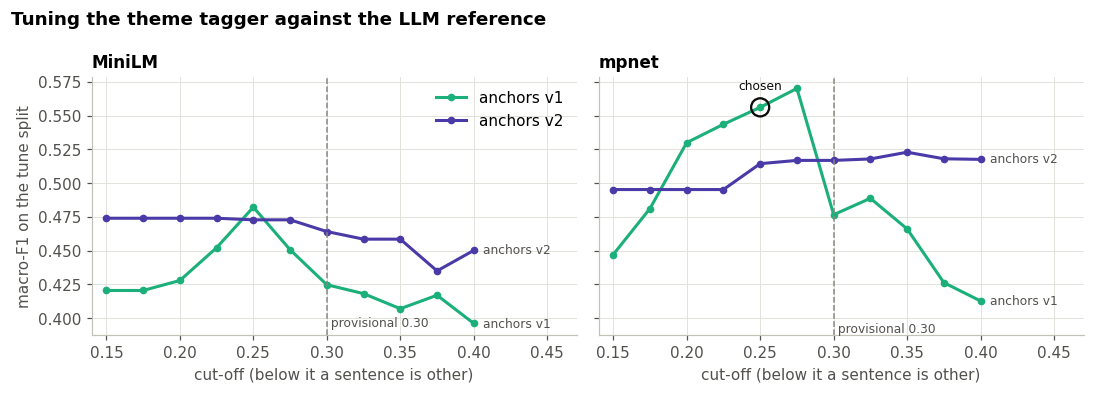

In [41]:
# 4.5 tuning on the 72 tune sentences only: model (MiniLM, mpnet) x anchors (v1, v2) x cut-off.
# Anchors v2 add bank-neutral descriptions where v1 missed on the tune split (buybacks, market share, NII
# outlook, integration timing, higher-for-longer rates) and a set for "other" (procedure, vague remarks), so a
# topic-less line can land on "other" by similarity and not only through the cut-off.
# Rule, fixed before the test split is used: best tune macro-F1 averaged over the cut-off and its two
# neighbours, so a lucky single cut-off on 72 sentences cannot win.
EXTRA_V2 = {
    "integration": [
        "When will the legal entities be merged, and when will the acquired clients be on one platform?",
        "How much of the integration work is still ahead of you, and what are the next milestones?",
    ],
    "capital": [
        "When do you expect to restart share buybacks, and at what size?",
        "How do you think about the payout split between dividends and buybacks over the next few years?",
        "The capital surcharge and the stress capital buffer set how much capital we must hold.",
    ],
    "risk": [
        "Rates staying higher for longer could strain borrowers and slow the economy.",
    ],
    "revenue": [
        "Net interest income guidance for next year depends on the path of rate cuts and the forward curve.",
        "We are winning back market share and client flows are returning.",
        "What is your outlook for revenue growth and returns over the next few years?",
    ],
}
ANCHORS_V2 = {t: ANCHORS_V1[t] + EXTRA_V2.get(t, []) for t in ANCHORS_V1}
ANCHORS_V2["other"] = [
    "Thank you, that is very helpful.",
    "Let me take your second question.",
    "I would just add one point to that.",
    "What exactly do you mean by that?",
    "We are not going to comment on speculation.",
    "That is a fair question, and we will come back to it.",
]
assert not any(BANK_NAMES.search(a) for v in ANCHORS_V2.values() for a in v), "an anchor names a bank"

scores = {("v1", tag): S for tag, S in scores_v1.items()}
scores.update({("v2", tag): theme_scores(tag, ANCHORS_V2) for tag in emb})
row = pd.Series(qa.index, index=qa["key"])          # position of each sentence in qa and in the score tables
CUTS = np.round(np.arange(0.15, 0.4001, 0.025), 3)

def gold_scores(setting, part):
    return scores[setting].iloc[row.loc[part["key"]].to_numpy()]

tune = ref[ref["split"] == "tune"]
records = []
for a, tag in scores:
    S = gold_scores((a, tag), tune)
    for cut in CUTS:
        pred = assign(S, cut).to_numpy()
        records.append({"anchors": a, "model": tag, "cut": cut, "accuracy": accuracy_score(tune["theme"], pred),
                        "macro_F1": macro_f1(tune["theme"], pred), "other_share": (pred == "other").mean()})
grid = pd.DataFrame(records)
grid["smoothed_F1"] = (grid.groupby(["anchors", "model"])["macro_F1"]
                       .transform(lambda s: s.rolling(3, center=True, min_periods=2).mean()))
best = grid.loc[grid["smoothed_F1"].idxmax()]
CHOSEN = (best["anchors"], best["model"], float(best["cut"]))
print(f"best cut-off per anchors and model ({len(tune)} tune sentences)")
display(grid.loc[grid.groupby(["anchors", "model"])["smoothed_F1"].idxmax()]
        .set_index(["anchors", "model"]).round(3))
print(f"chosen: anchors {CHOSEN[0]}, {CHOSEN[1]}, cut-off {CHOSEN[2]:.3f}")

ANCHOR_COLOR = {"v1": "#1baf7a", "v2": "#4a3aa7"}   # not the bank colours; checked for colour-blind separation
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, tag in zip(axes, emb):
    for a in ("v1", "v2"):
        g = grid[(grid["anchors"] == a) & (grid["model"] == tag)]
        ax.plot(g["cut"], g["macro_F1"], color=ANCHOR_COLOR[a], marker="o", ms=4, label=f"anchors {a}")
        ax.annotate(f"anchors {a}", (g["cut"].iloc[-1], g["macro_F1"].iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=8, color="#52514e")
    ax.axvline(THRESH_V1, color="#898781", lw=1, ls="--")
    ax.text(THRESH_V1, ax.get_ylim()[0], " provisional 0.30", fontsize=8, color="#52514e", va="bottom")
    if tag == CHOSEN[1]:
        g = grid[(grid["anchors"] == CHOSEN[0]) & (grid["model"] == tag) & (grid["cut"] == CHOSEN[2])]
        ax.scatter(g["cut"], g["macro_F1"], s=140, facecolors="none", edgecolors="#0b0b0b", lw=1.5, zorder=3)
        ax.annotate("chosen", (CHOSEN[2], g["macro_F1"].iloc[0]), xytext=(0, 12), textcoords="offset points",
                    ha="center", fontsize=8, color="#0b0b0b")
    ax.set_xlim(CUTS[0] - 0.01, CUTS[-1] + 0.07)
    ax.set_title(tag, loc="left")
    ax.set_xlabel("cut-off (below it a sentence is other)")
axes[0].set_ylabel("macro-F1 on the tune split")
axes[0].legend(loc="upper right")
fig.suptitle("Tuning the theme tagger against the LLM reference", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

In [42]:
# 4.5b the only look at the test split: the provisional setting (anchors v1, MiniLM, 0.30) against the chosen
# one, with 95% bootstrap intervals over the 48 sentences. Small sample: read the intervals, not the decimals.
from sklearn.metrics import classification_report

test = ref[ref["split"] == "test"]
y = test["theme"].to_numpy()
SETTINGS = {"before (v1, MiniLM, 0.30)": ("v1", "MiniLM", THRESH_V1),
            f"after ({CHOSEN[0]}, {CHOSEN[1]}, {CHOSEN[2]:.3f})": CHOSEN}
boot = np.random.default_rng(SEED).integers(0, len(y), size=(1000, len(y)))

def interval(metric, p):
    lo, hi = np.percentile([metric(y[i], p[i]) for i in boot], [2.5, 97.5])
    return f"{lo:.2f} to {hi:.2f}"

rows, preds = [], {}
for name, (a, tag, cut) in SETTINGS.items():
    p = preds[name] = assign(gold_scores((a, tag), test), cut).to_numpy()
    rows.append({"setting": name, "accuracy": round(accuracy_score(y, p), 2), "95% interval": interval(accuracy_score, p),
                 "macro-F1": round(macro_f1(y, p), 2), "95% interval ": interval(macro_f1, p),
                 "other share": round((p == "other").mean(), 2)})
print(f"{len(test)} test sentences, scored against the LLM reference (prompt v2)")
display(pd.DataFrame(rows).set_index("setting"))
print("after tuning, per theme")
print(classification_report(y, preds[list(SETTINGS)[1]], zero_division=0))

48 test sentences, scored against the LLM reference (prompt v2)


,accuracy,95% interval,macro-F1,95% interval,other share
setting,,,,,
"before (v1, MiniLM, 0.30)",0.48,0.33 to 0.60,0.43,0.28 to 0.53,0.35
"after (v1, mpnet, 0.250)",0.48,0.35 to 0.60,0.42,0.28 to 0.53,0.25


after tuning, per theme
               precision    recall  f1-score   support

      capital       0.50      0.38      0.43         8
        costs       0.50      0.75      0.60         4
  integration       0.60      0.38      0.46         8
        other       0.58      0.58      0.58        12
restructuring       0.00      0.00      0.00         0
      revenue       0.57      0.40      0.47        10
         risk       0.33      0.50      0.40         6

     accuracy                           0.48        48
    macro avg       0.44      0.43      0.42        48
 weighted avg       0.53      0.48      0.49        48



In [43]:
# 4.5c the chosen setting tags the whole corpus; theme shares by bank before and after tuning (% of clean
# Q&A sentences). Saved per sentence for the other tracks (FinBERT sentiment by theme, Step 4.9).
qa["theme"] = assign(scores[CHOSEN[:2]], CHOSEN[2]).to_numpy()
shares = pd.concat({"before": pd.crosstab(qa["theme_v1_MiniLM"], qa["bank"], normalize="columns"),
                    "after": pd.crosstab(qa["theme"], qa["bank"], normalize="columns")}, axis=1)
display(shares.mul(100).round(1).reindex(THEMES).fillna(0))
qa[["key", "sentence_id", "theme"]].to_csv(OUT / "themes_sentence.csv", index=False)
print(f"wrote themes_sentence.csv: {len(qa):,} sentences, anchors {CHOSEN[0]}, {CHOSEN[1]}, cut-off {CHOSEN[2]:.3f}")

before       after      
bank             JPM   UBS   JPM   UBS
integration      3.2   6.9   4.6   9.8
restructuring    4.2   9.2   2.5   7.8
capital         12.1  15.7  17.3  17.9
risk            15.9   8.7  21.9  14.2
costs            6.1  12.3   8.4  16.9
revenue         20.7  15.5  15.1  11.5
other           37.8  31.8  30.3  22.0

wrote themes_sentence.csv: 4,519 sentences, anchors v1, mpnet, cut-off 0.250


## Next

Stop here. Run the three 4.5 cells (about a minute, no LLM calls: the labels load from the file), then share the saved notebook. Steps 4.6 to 4.10 (theme shares over time, drift, analyst-management gap, summary and slide) are written from those results.